# Experiments

This section contains the experiments and analyses **below** “Abnormal signal session results”.
- Paths are standardized.
- Duplicated/unused code blocks were removed.
- Results are saved under `../rus/01_label_and_scenario_sanity_checks/` by default.


## Setup

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

from pathlib import Path

import matplotlib.colors as mcolors
import seaborn as sns

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from matplotlib.lines import Line2D

from src.datasets.biosignal_dataset import BioSignalDataset

SEED = 42
np.random.seed(SEED)

# project paths (notebook is assumed to be in repo root or under notebooks/)
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / "src").exists() else NB_DIR.parent

DATA_DIR = (REPO_ROOT / "data").resolve()          # ../data
RUNS_DIR = (REPO_ROOT / "runs" / "01_label_and_scenario_sanity_checks").resolve()

RUNS_DIR.mkdir(parents=True, exist_ok=True)
print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR :", DATA_DIR)
print("RUNS_DIR :", RUNS_DIR)

REPO_ROOT: <REPO_ROOT>
DATA_DIR : <REPO_ROOT>/data
RUNS_DIR : <REPO_ROOT>/runs/01_label_and_scenario_sanity_checks


## Input files (expected)

Required:
- `../data/alcohol_scenarios.csv`

In [2]:
# Resolve key input paths (fail fast with helpful messages)
SCENARIO_INFO_CSV = DATA_DIR / "alcohol_scenarios.csv"

if not SCENARIO_INFO_CSV.exists():
    raise FileNotFoundError(f"Missing: {SCENARIO_INFO_CSV}")


## Load Data

In [3]:
split_data_dir = r'/path/to/split_data/alcohol'

subject_list = os.listdir(split_data_dir)

alcohol_data = BioSignalDataset(split_data_dir, 'ECG', 'PPG', 'GSR')

labels = alcohol_data.get_labels(DATA_DIR / "labels/alcohol.json")

## Q1 vs Q2 correlation (per session & overall)

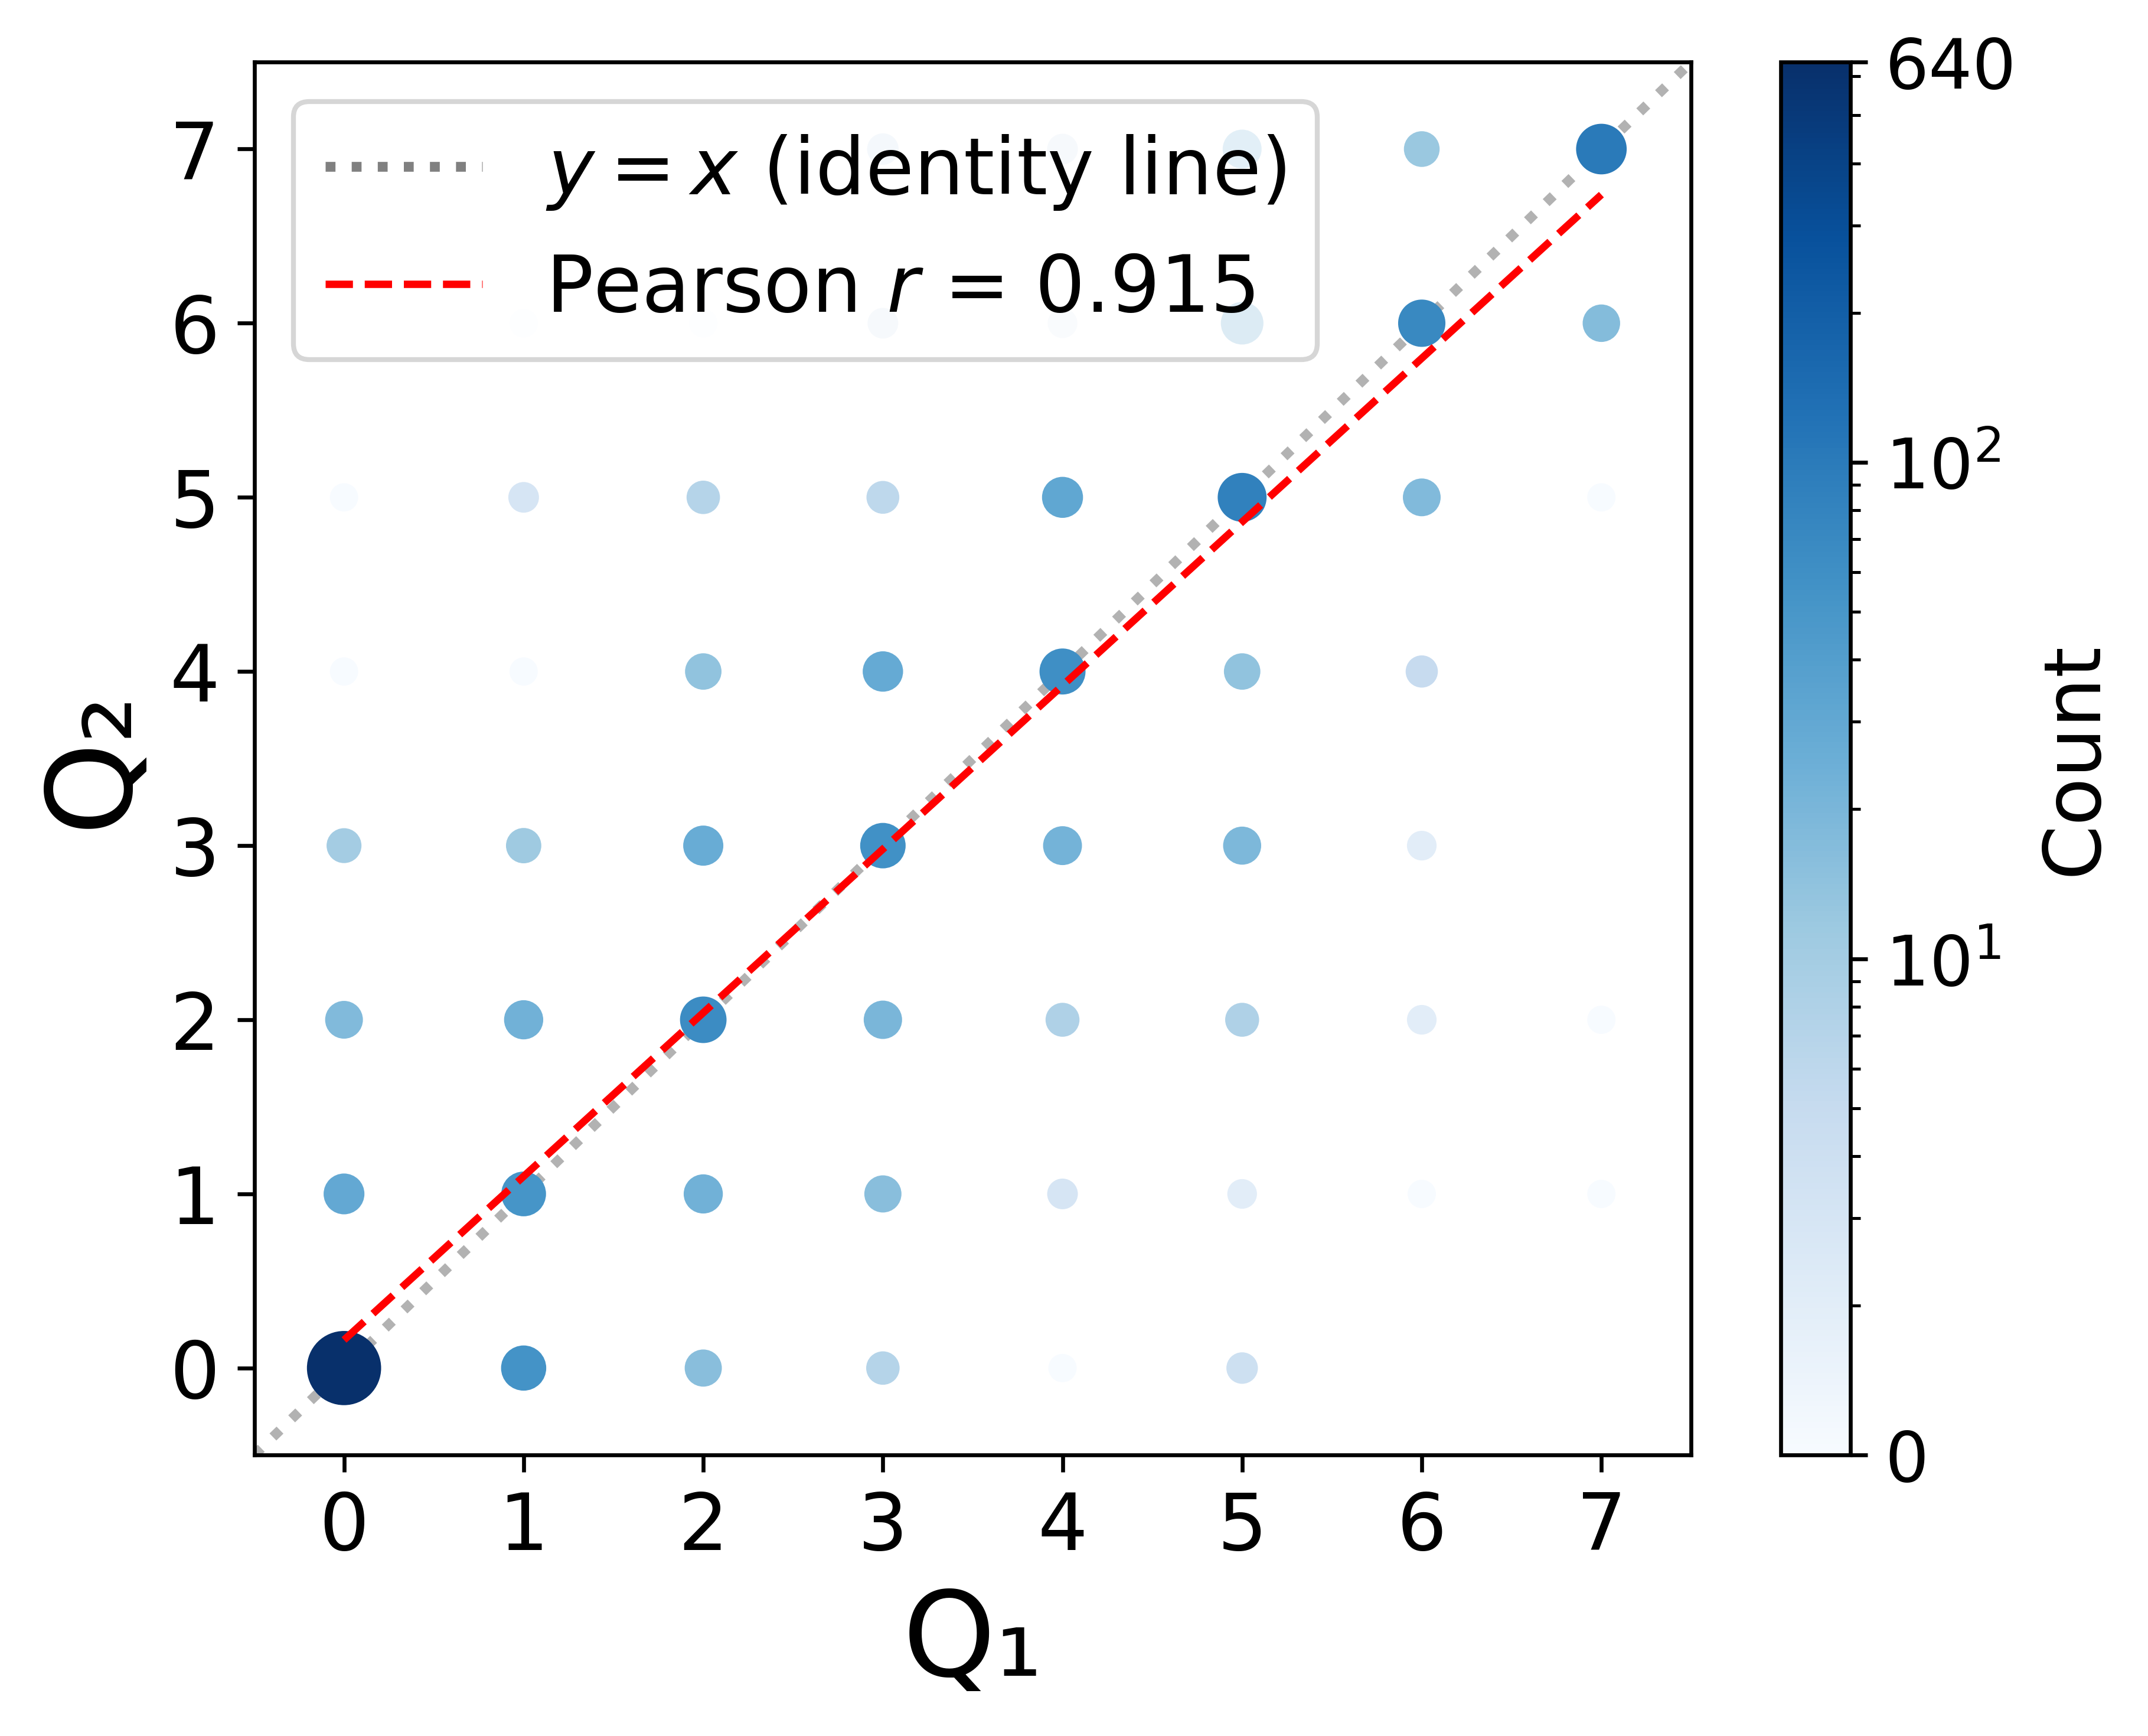

{'n': 1697, 'pearson_r': 0.9146739287554382, 'pearson_p': 0.0}


In [4]:
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# -----------------------------
# flatten Q1-Q2
# -----------------------------
def flatten_q1_q2(labels: dict) -> pd.DataFrame:
    rows = []
    for subj, subj_dict in labels.items():
        for video, video_dict in subj_dict.items():
            for trial, qdict in video_dict.items():
                rows.append({
                    "subject": subj,
                    "video": video,
                    "trial": trial,
                    "Q1": qdict.get("Q1", np.nan),
                    "Q2": qdict.get("Q2", np.nan),
                })
    return pd.DataFrame(rows)


def q1_q2_correlation(
    labels: dict,
    save_path: str | None = None,
    dpi: int = 600,
    use_log_color: bool = True,
):
    df = flatten_q1_q2(labels)

    # clean
    df["Q1"] = pd.to_numeric(df["Q1"], errors="coerce")
    df["Q2"] = pd.to_numeric(df["Q2"], errors="coerce")
    df = df.dropna(subset=["Q1", "Q2"])
    df = df[np.isfinite(df["Q1"]) & np.isfinite(df["Q2"])]

    # (0~7) 정수화
    df["Q1_int"] = np.rint(df["Q1"].to_numpy()).astype(int)
    df["Q2_int"] = np.rint(df["Q2"].to_numpy()).astype(int)
    df = df[(df["Q1_int"].between(0, 7)) & (df["Q2_int"].between(0, 7))]

    # ✅ Pearson correlation 다시 계산
    if len(df) >= 2:
        r_p, p_p = pearsonr(df["Q1_int"], df["Q2_int"])
    else:
        r_p, p_p = np.nan, np.nan

    res = {
        "n": int(len(df)),
        "pearson_r": float(r_p) if np.isfinite(r_p) else np.nan,
        "pearson_p": float(p_p) if np.isfinite(p_p) else np.nan,
    }

    # -----------------------------
    # count 기반 scatter용 집계
    # -----------------------------
    counts_df = (
        df.groupby(["Q1_int", "Q2_int"])
          .size()
          .reset_index(name="count")
          .sort_values("count", ascending=True)
    )

    # -------- plot --------
    fig, ax = plt.subplots(figsize=(6.2, 5), dpi=dpi)

    norm = (
        mcolors.LogNorm(
            vmin=max(1, counts_df["count"].min()),
            vmax=counts_df["count"].max()
        )
        if use_log_color else None
    )

    sizes = 25 + 8 * np.sqrt(counts_df["count"])
    sizes = np.clip(sizes, 30, 250)

    ax.plot(
        [-0.5, 7.5], [-0.5, 7.5],
        linestyle=":",
        linewidth=2,
        color="gray",
        alpha=0.6,
        zorder=1
    )

    sc = ax.scatter(
        counts_df["Q1_int"],
        counts_df["Q2_int"],
        c=counts_df["count"],
        cmap="Blues",
        norm=norm,
        s=sizes,
        edgecolors="none",
        zorder=2
    )

    # -----------------------------
    # colorbar tick 설정
    # -----------------------------
    vmin = max(1, int(counts_df["count"].min()))
    vmax = int(counts_df["count"].max())

    if use_log_color:
        tick_min_exp = int(np.floor(np.log10(vmin)))
        tick_max_exp = int(np.floor(np.log10(vmax)))
        ticks = [10 ** i for i in range(tick_min_exp, tick_max_exp + 1)]

        # 최댓값이 기존 tick에 없으면 추가
        if vmax not in ticks:
            ticks.append(vmax)

        ticks = sorted(set(ticks))

        cbar = plt.colorbar(sc, ax=ax, ticks=ticks)

        tick_labels = []
        for t in ticks:
            if np.isclose(np.log10(t), round(np.log10(t))):
                tick_labels.append(rf"$10^{{{int(round(np.log10(t)))}}}$" if int(round(np.log10(t))) != 0 else '0')
            else:
                tick_labels.append(str(int(t)))
        cbar.set_ticklabels(tick_labels)

    else:
        ticks = sorted(set([vmin, vmax]))
        cbar = plt.colorbar(sc, ax=ax, ticks=ticks)
        cbar.set_ticklabels([str(int(t)) for t in ticks])

    cbar.set_label("Count", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    # 회귀선
    sns.regplot(
        data=df,
        x="Q1_int",
        y="Q2_int",
        scatter=False,
        ci=None,
        color="red",
        line_kws={"linewidth": 1.5, "linestyle": "--"},
        ax=ax
    )

    # legend
    diag_line = Line2D(
        [0], [0],
        color="gray",
        linestyle=":",
        linewidth=2,
        label=r"$y = x$ (identity line)"
    )

    reg_label = rf"Pearson $r$ = {r_p:.3f}" if np.isfinite(r_p) else "Pearson r = NaN"
    reg_line = Line2D(
        [0], [0],
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=reg_label
    )

    ax.legend(handles=[diag_line, reg_line], loc="upper left", frameon=True, fontsize=16)

    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(-0.5, 7.5)
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.tick_params(axis="both", which="major", labelsize=16)

    ax.set_xlabel("Q\u2081", fontsize=24)
    ax.set_ylabel("Q\u2082", fontsize=24)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    return res, df


res_q12, df_q12 = q1_q2_correlation(
    labels,
    save_path=RUNS_DIR / "pearson_corr_q1_q2.png"
)

print(res_q12)

In [5]:
df_q12

,subject,video,trial,Q1,Q2,Q1_int,Q2_int
0,1_1_001,V1,low1,4,2,4,2
1,1_1_001,V1,low2,1,0,1,0
2,1_1_001,V1,low3,1,0,1,0
3,1_1_001,V1,low4,1,0,1,0
4,1_1_001,V1,low5,1,0,1,0
...,...,...,...,...,...,...,...
1692,1_2_013,V2,high2,0,0,0,0
1693,1_2_013,V2,high3,0,0,0,0
1694,1_2_013,V2,high4,0,0,0,0
1695,1_2_013,V2,high5,0,0,0,0


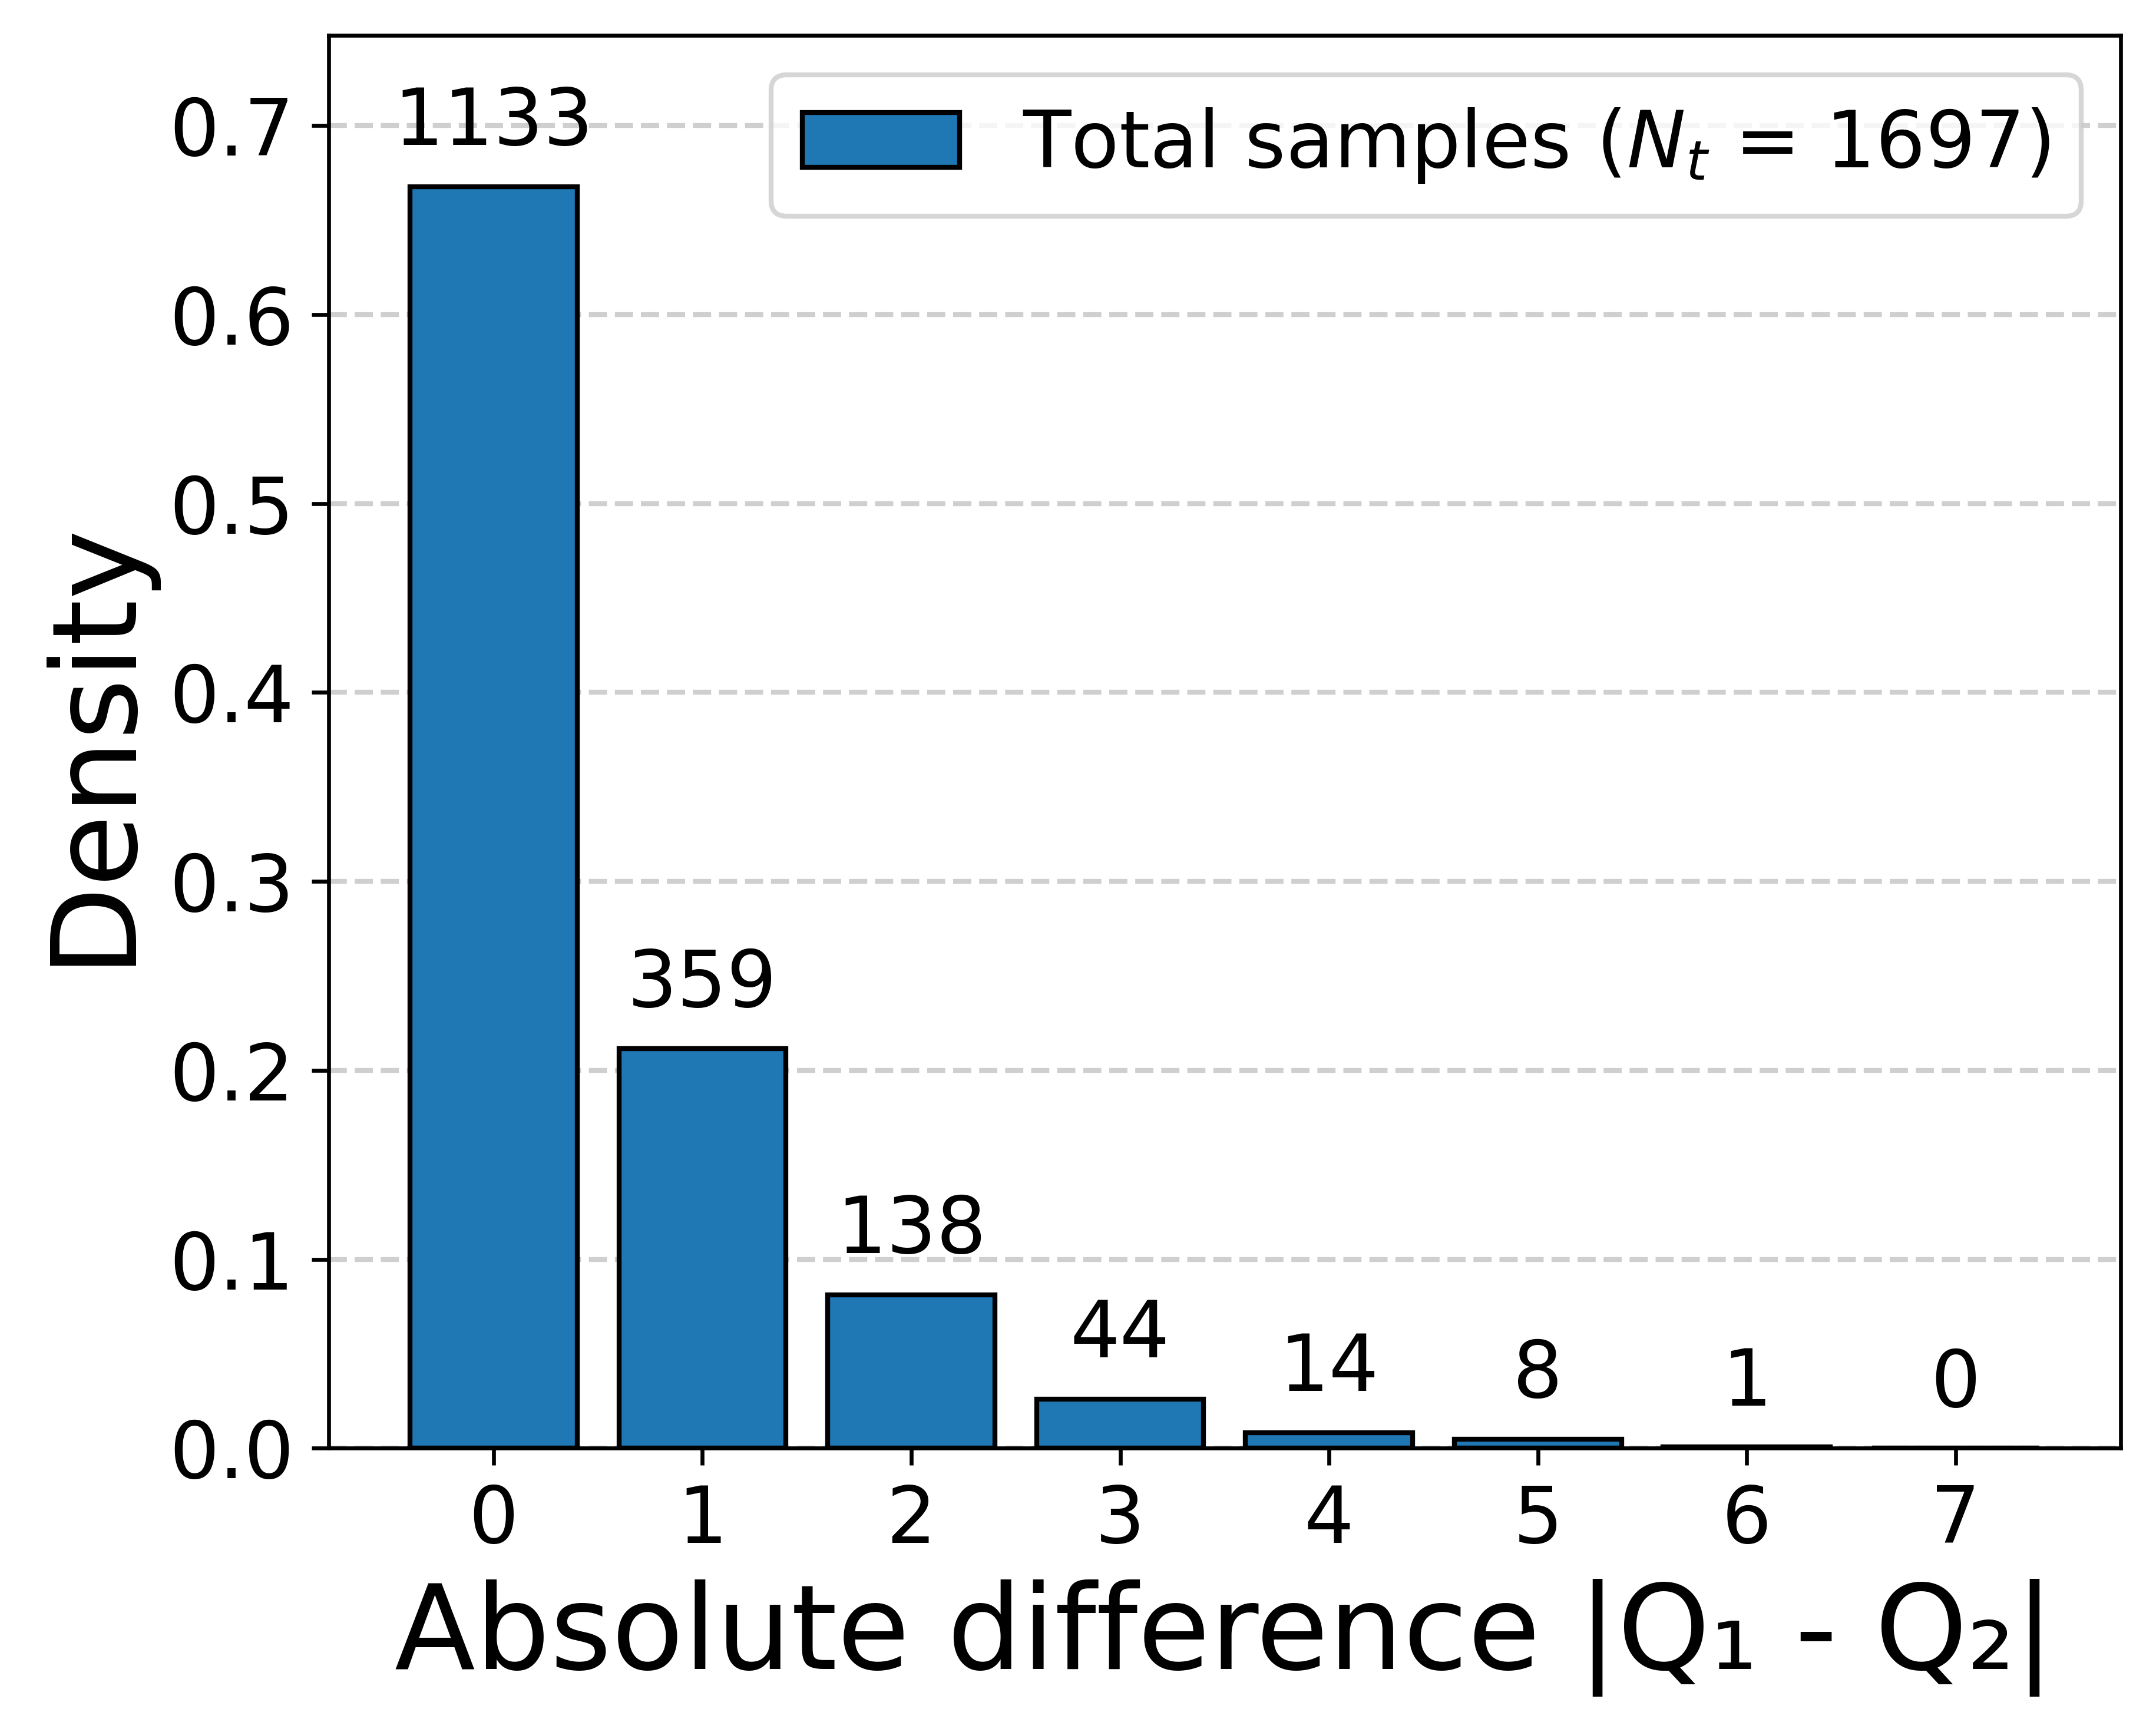

In [6]:
def plot_q1_q2_absdelta_bar(
    df,
    q1_col="Q1",
    q2_col="Q2",
    save_path=None,
    dpi=600,
    annotate=True,
):
    d = df[[q1_col, q2_col]].copy()
    d[q1_col] = pd.to_numeric(d[q1_col], errors="coerce")
    d[q2_col] = pd.to_numeric(d[q2_col], errors="coerce")
    d = d.dropna()

    q1 = np.rint(d[q1_col].to_numpy()).astype(int)
    q2 = np.rint(d[q2_col].to_numpy()).astype(int)
    mask = (0 <= q1) & (q1 <= 7) & (0 <= q2) & (q2 <= 7)
    q1, q2 = q1[mask], q2[mask]

    absd = np.abs(q2 - q1)
    n = int(len(absd))

    counts = np.bincount(absd, minlength=8)  # 0~7
    density = counts / n if n > 0 else np.zeros_like(counts, dtype=float)

    fig, ax = plt.subplots(figsize=(6.2, 5), dpi=dpi)

    bars = ax.bar(
        range(8),
        density,
        edgecolor="black",
        linewidth=1,
        label=rf"Total samples ($N_t$ = {n})",
    )
    
    ax.set_xticks(range(8))
    ax.set_xlabel("Absolute difference |Q\u2081 - Q\u2082|", fontsize=24)
    ax.set_ylabel("Density", fontsize=24)
    # ax.set_title("Absolute Difference Distribution")/
    ax.tick_params(labelsize=16)

    # ✅ y-grid
    ax.grid(axis="y", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_axisbelow(True)

    # ✅ y-limit 자동 확장 (텍스트 공간 확보)
    ymax = density.max()
    ax.set_ylim(0, ymax * 1.12)

    # ✅ bar 위 count 표시 (clipping 방지)
    if annotate:
        y_offset = ymax * 0.02
        for i, b in enumerate(bars):
            h = b.get_height()
            
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + y_offset,
                f"{counts[i]}",
                ha="center",
                va="bottom",
                fontsize=16,
                clip_on=True   # ✅ 축 밖으로 못 나가게
            )

    ax.legend(frameon=True, fontsize=16)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    return {
        "n": n,
        "counts_absdiff_0to7": counts.tolist(),
        "density_absdiff_0to7": density.tolist(),
    }

res = plot_q1_q2_absdelta_bar(df_q12, save_path= RUNS_DIR / "absolute_diff_histogram_q1_q2.png")

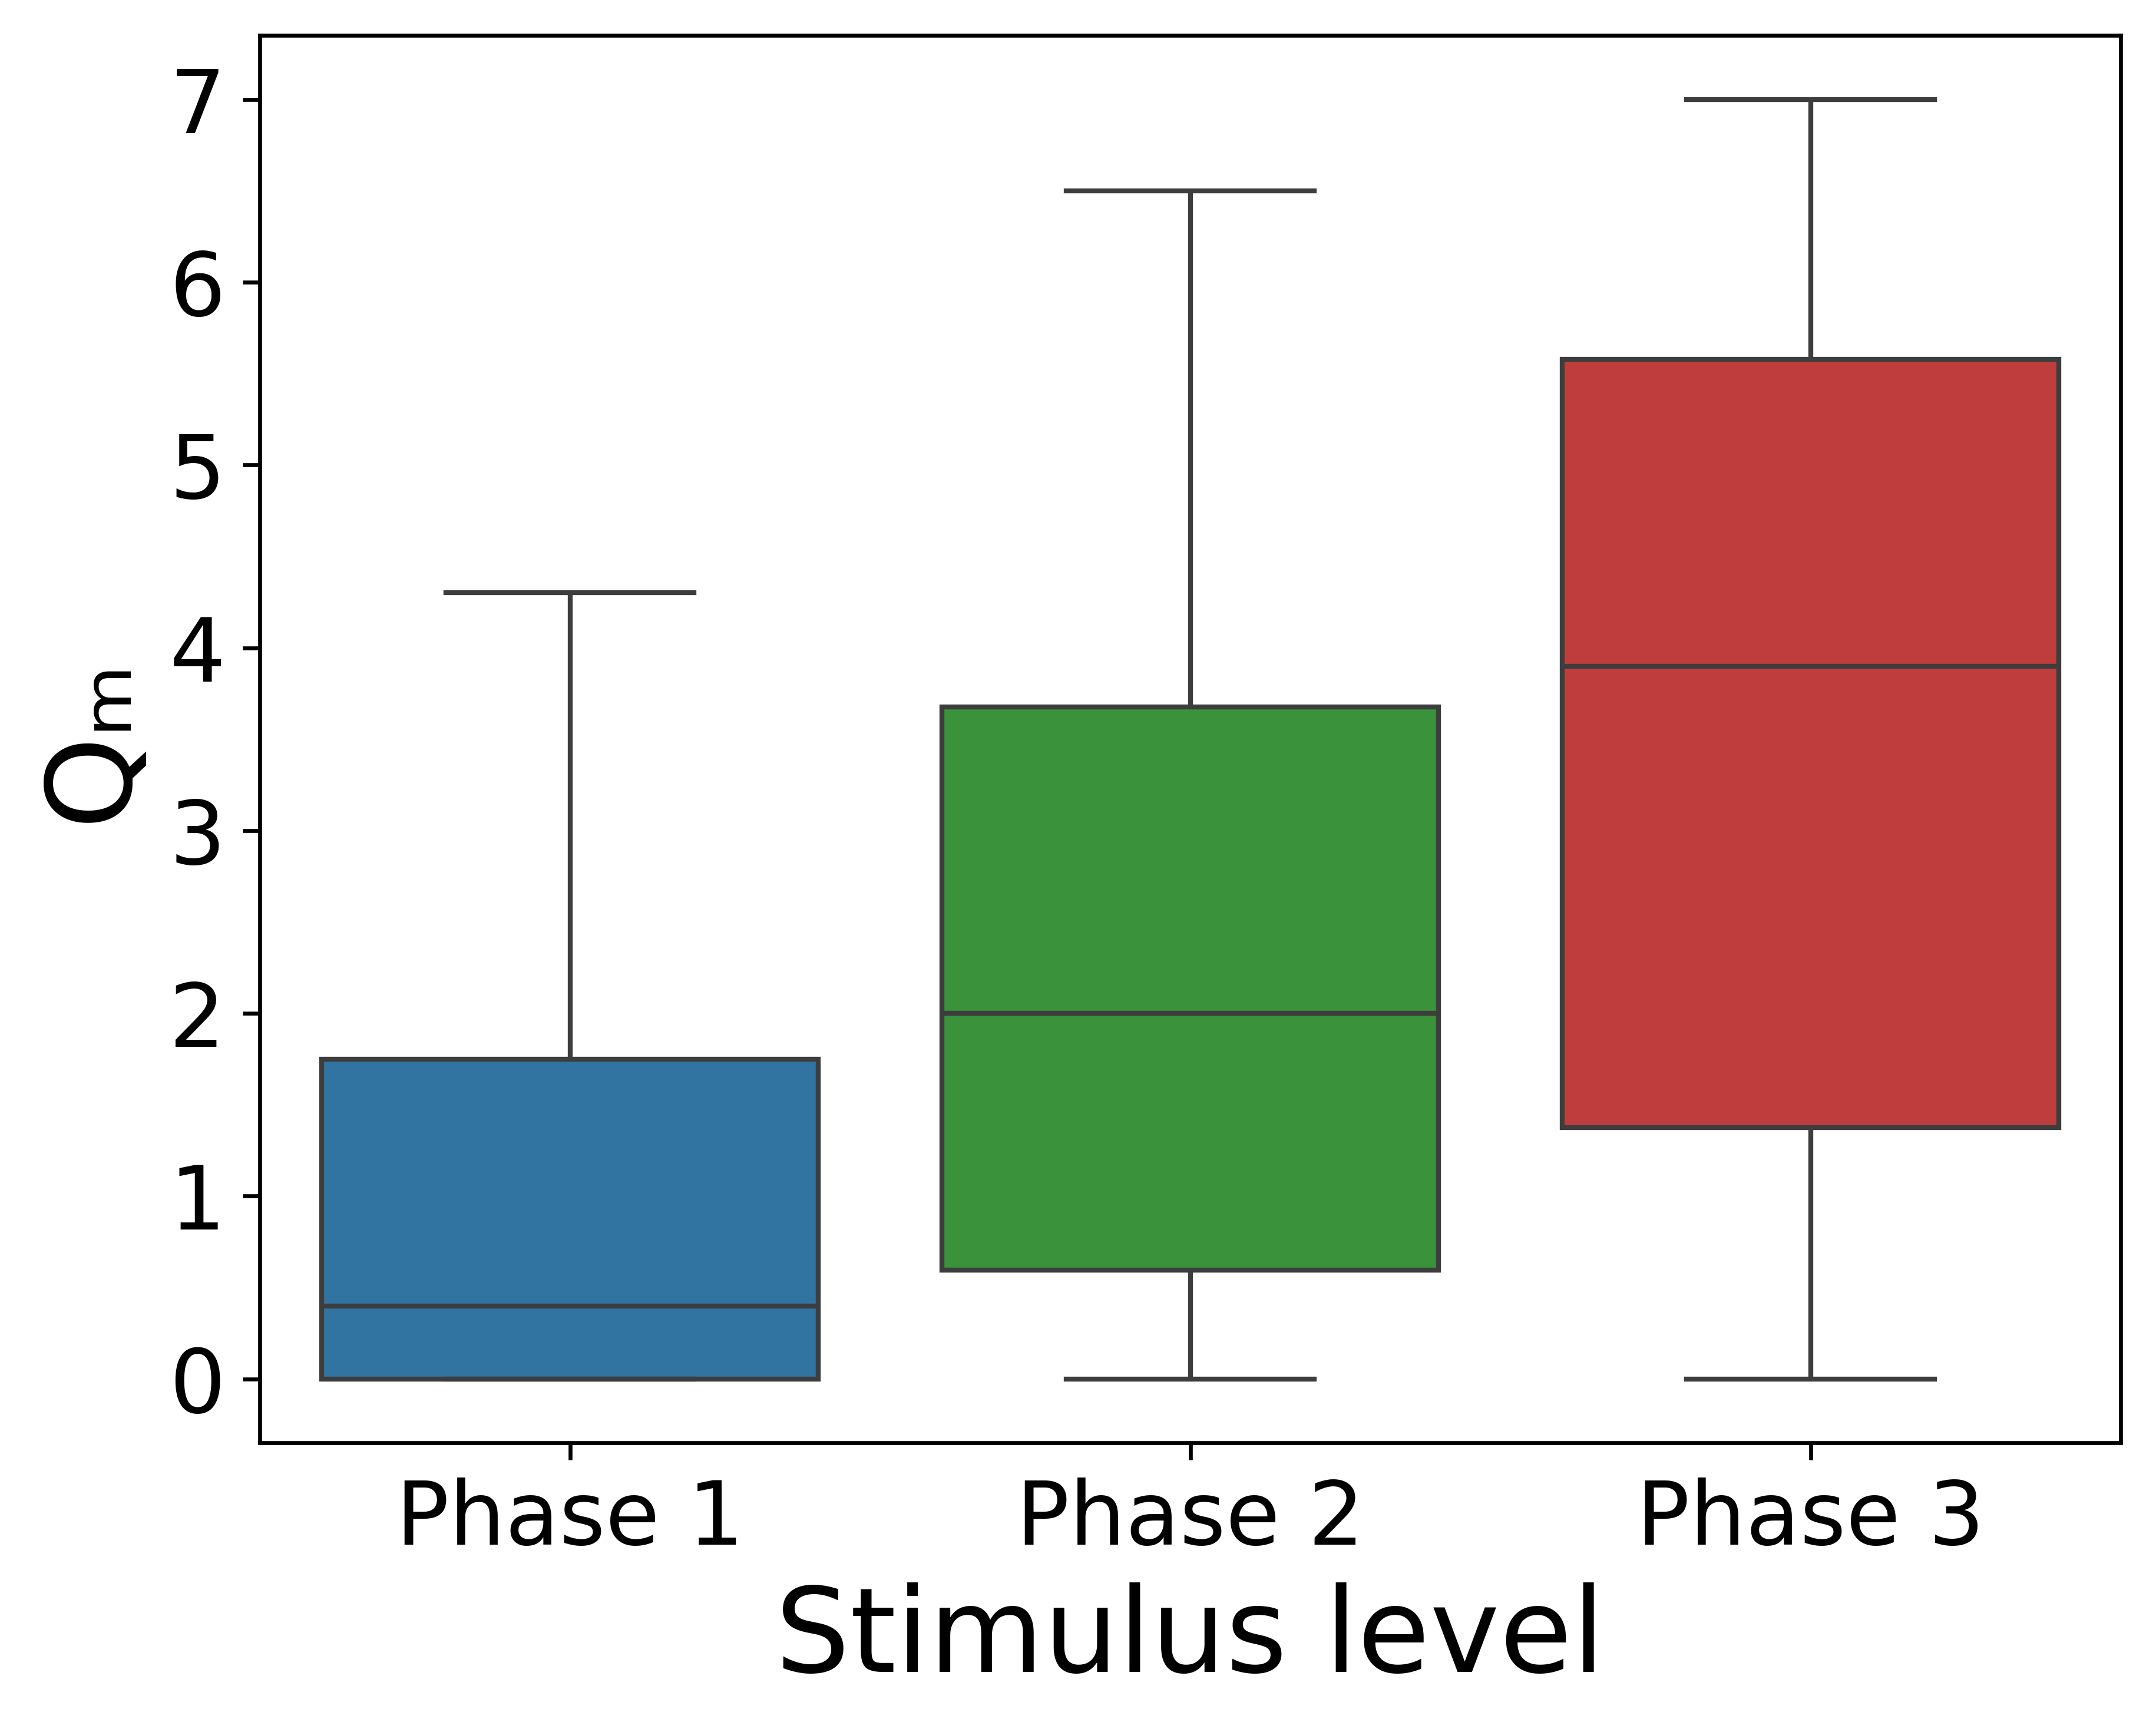

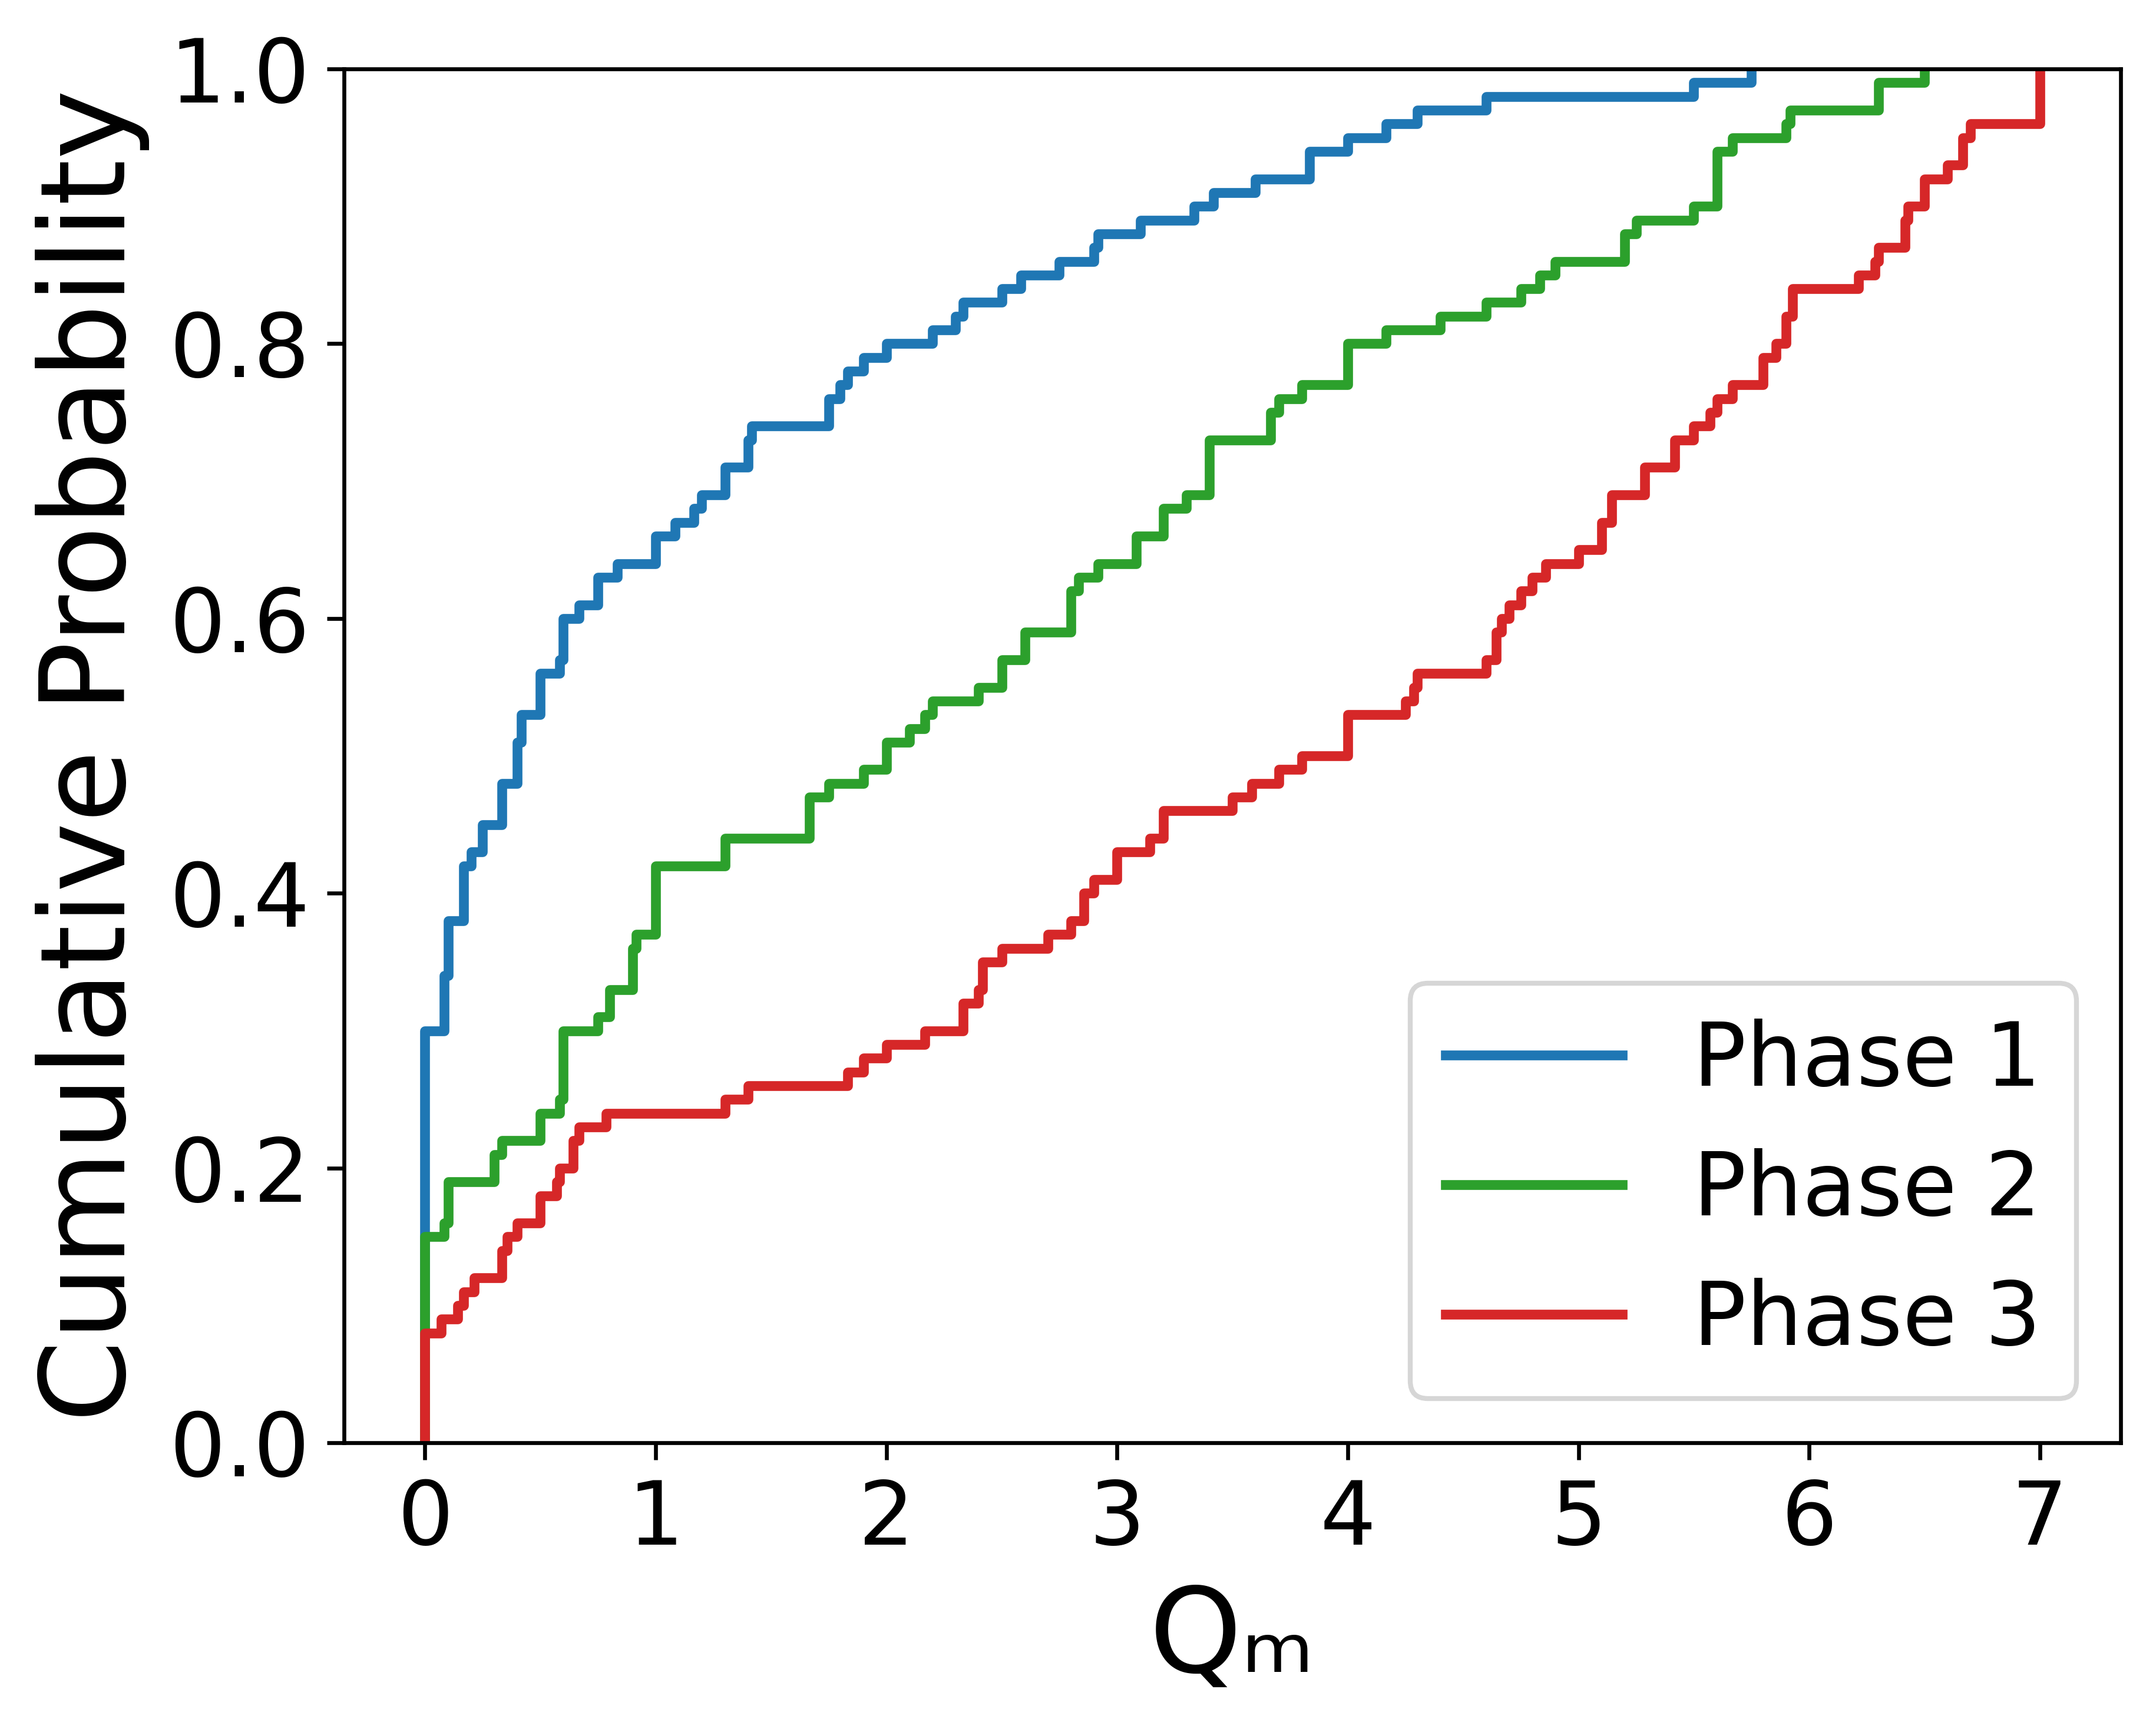

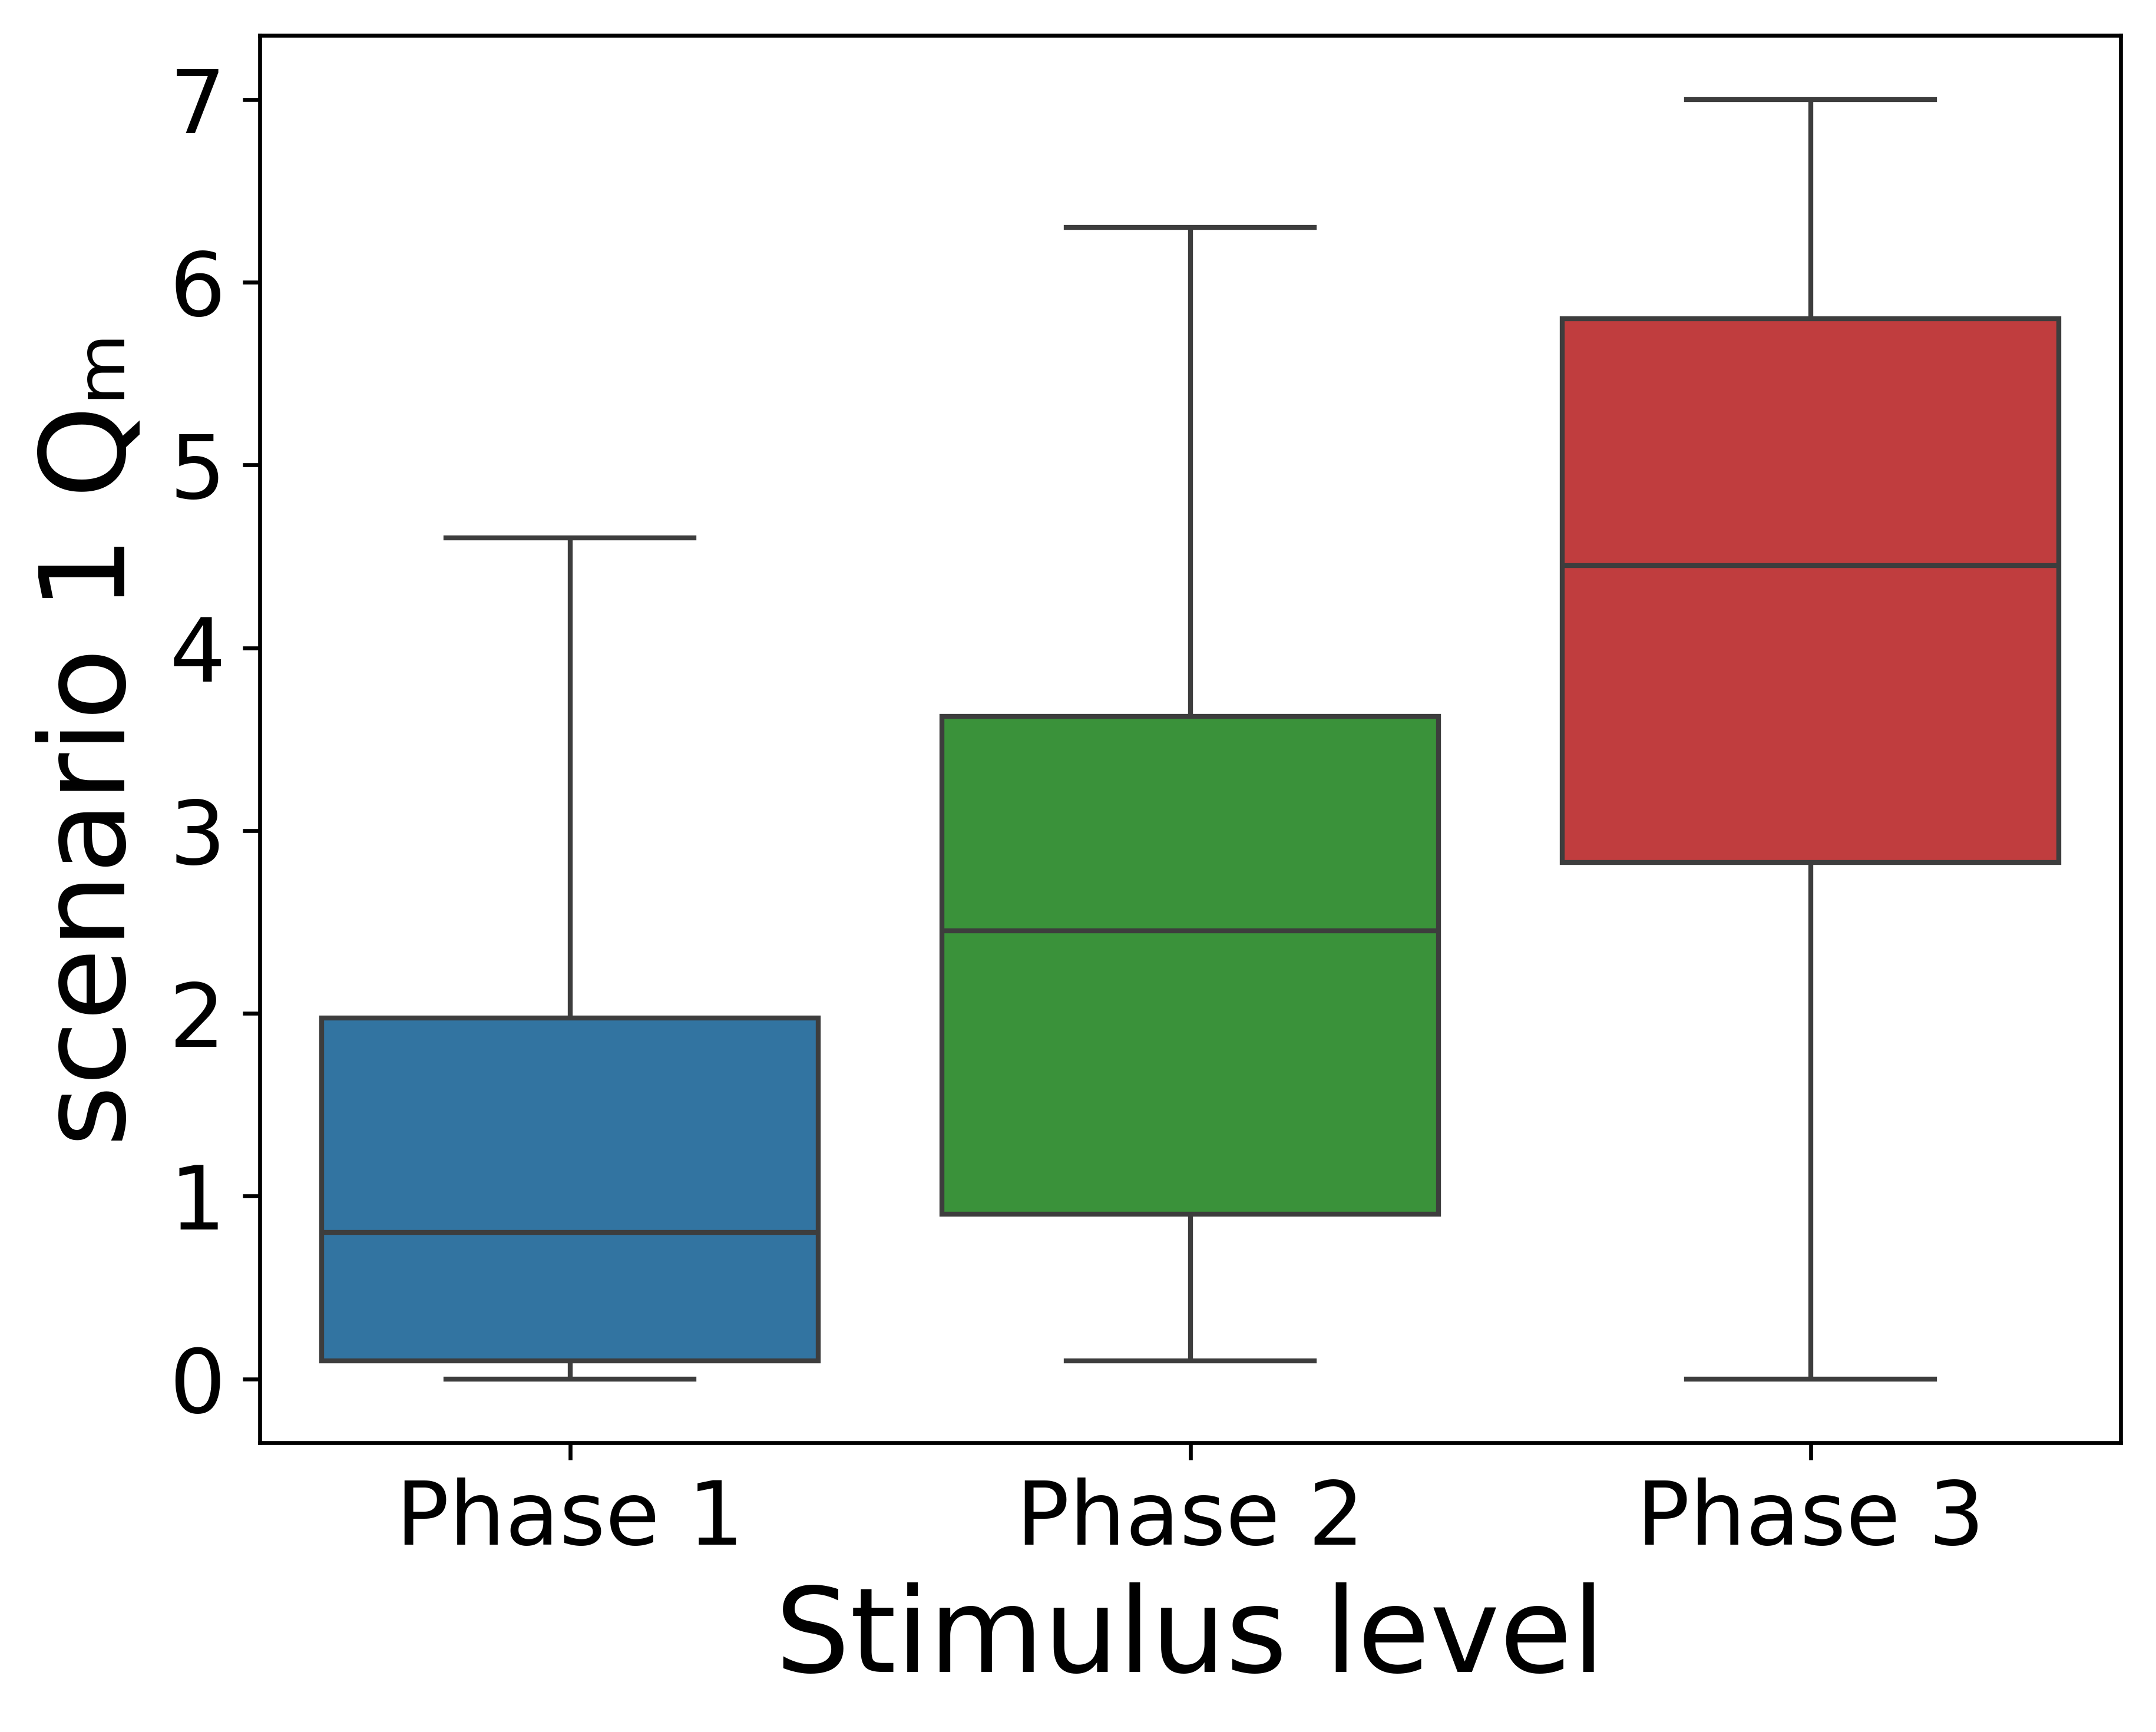

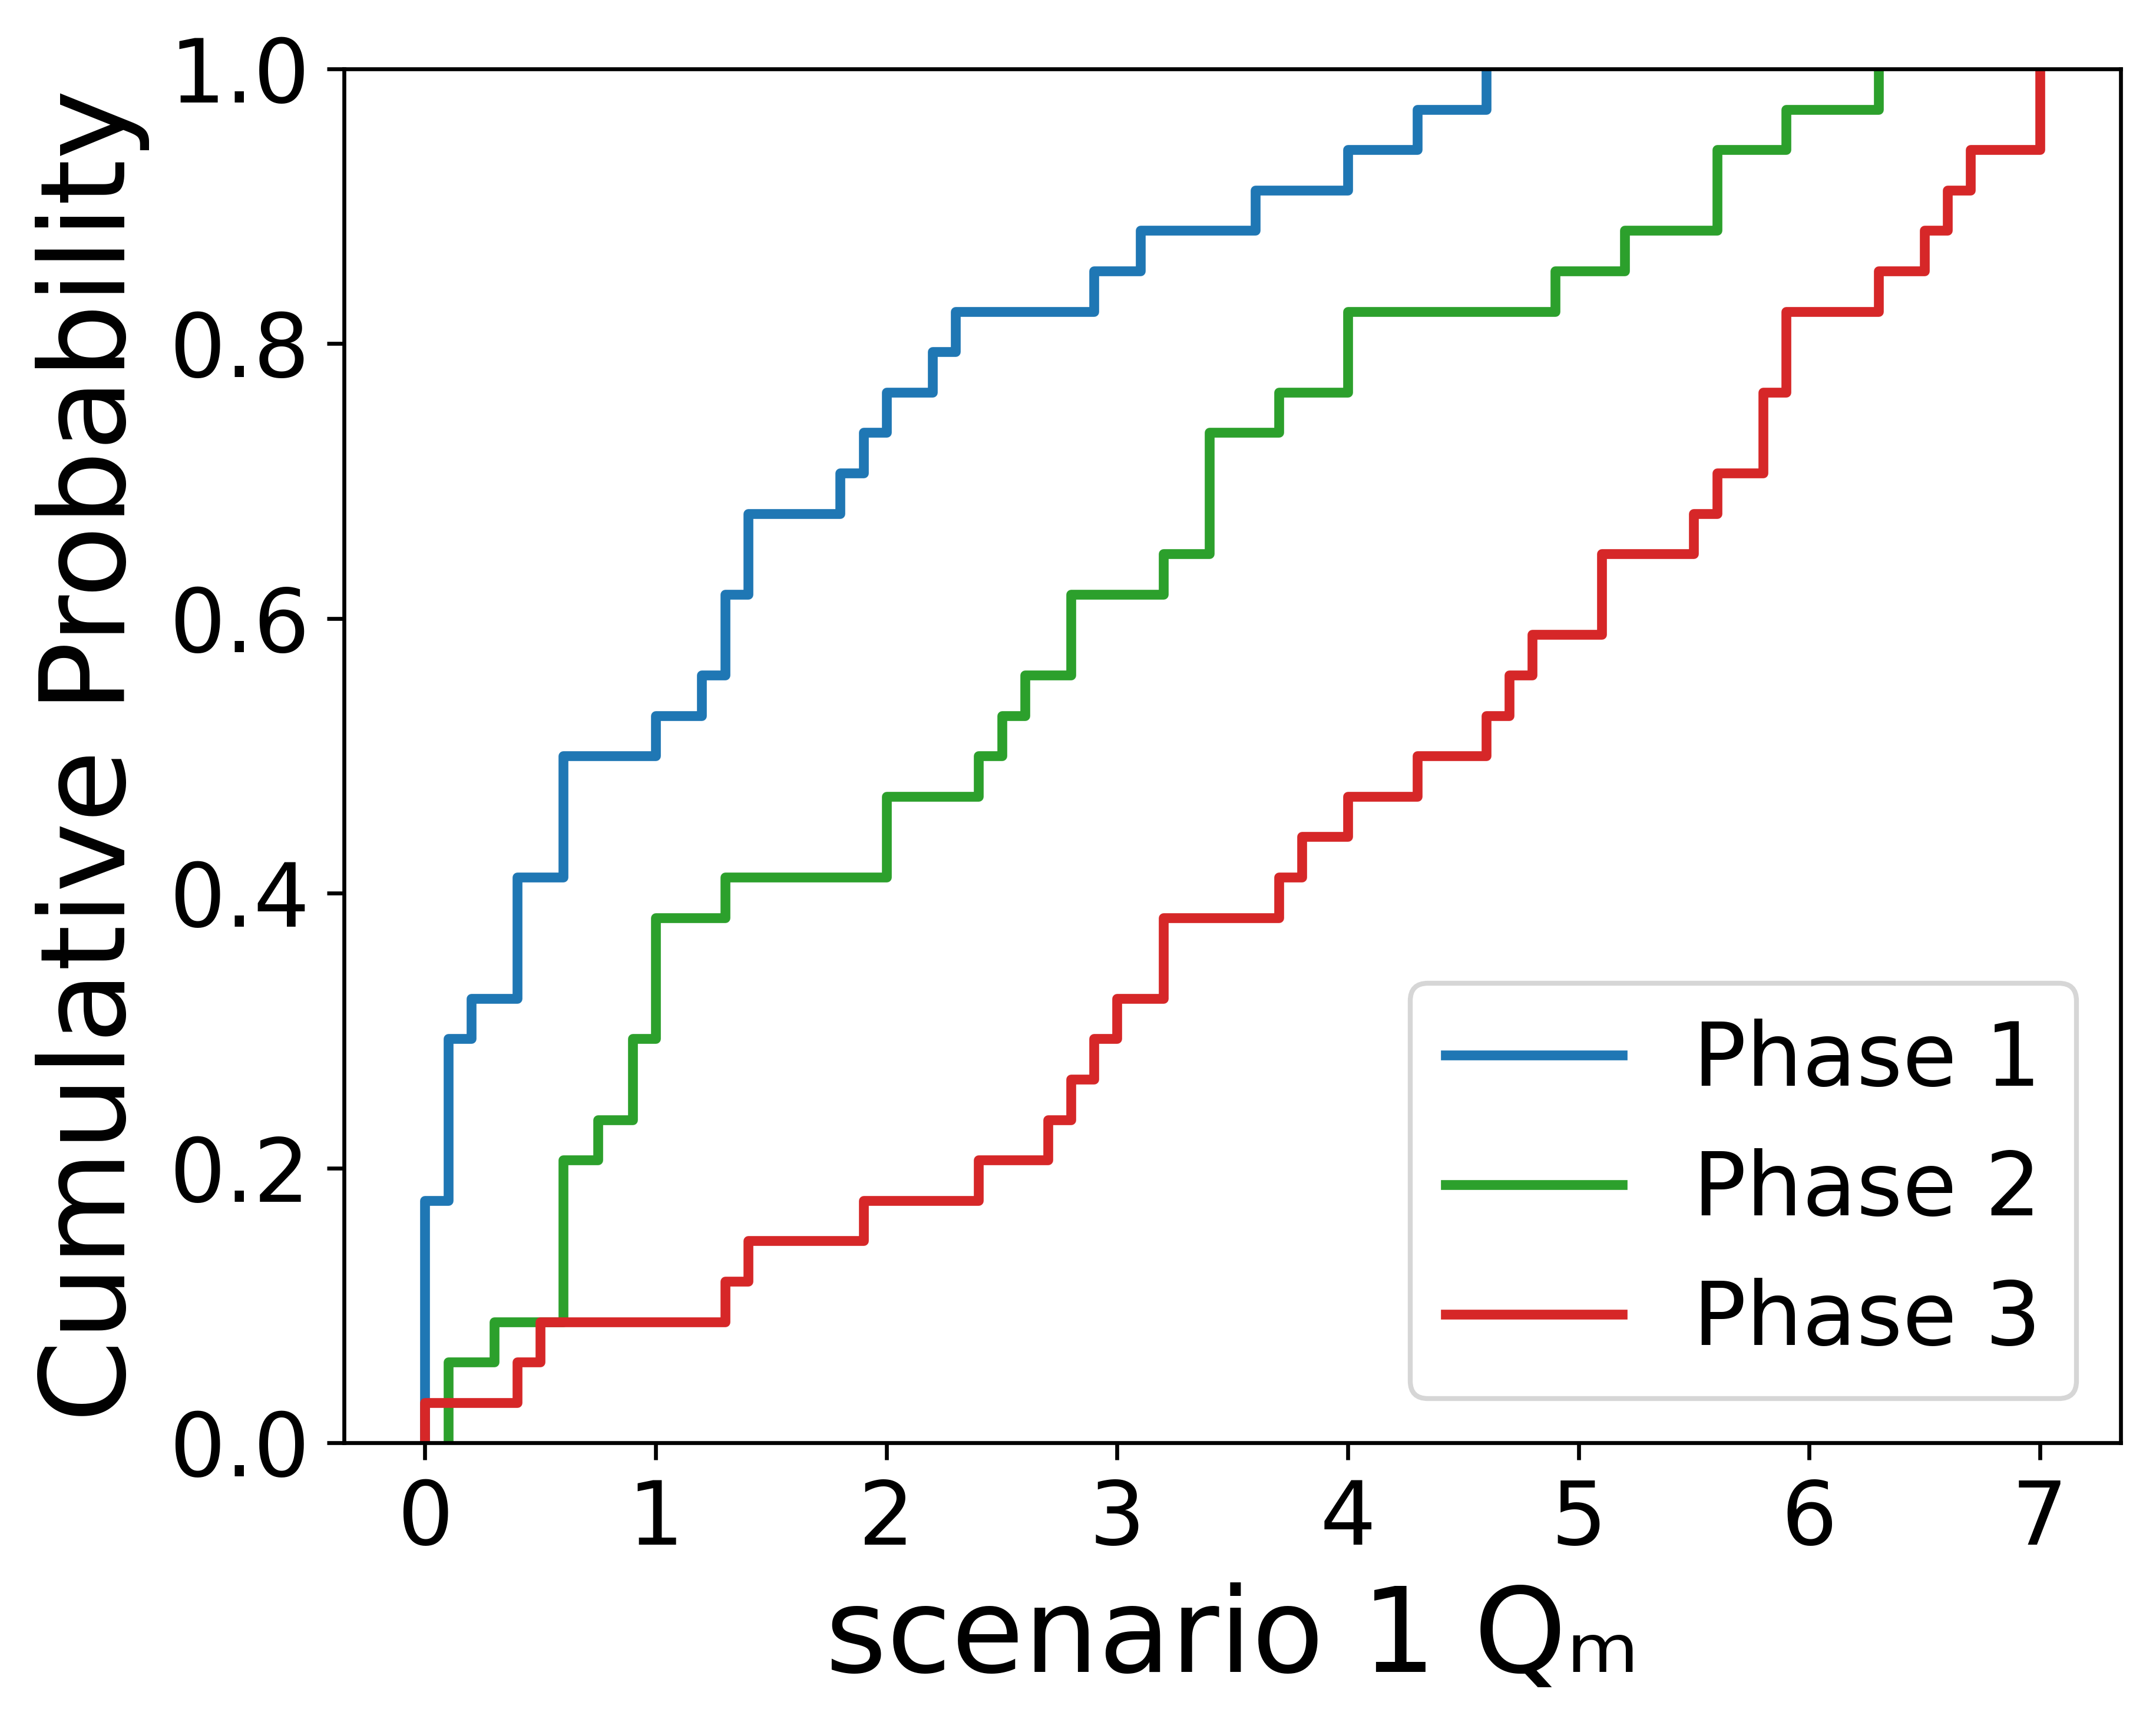

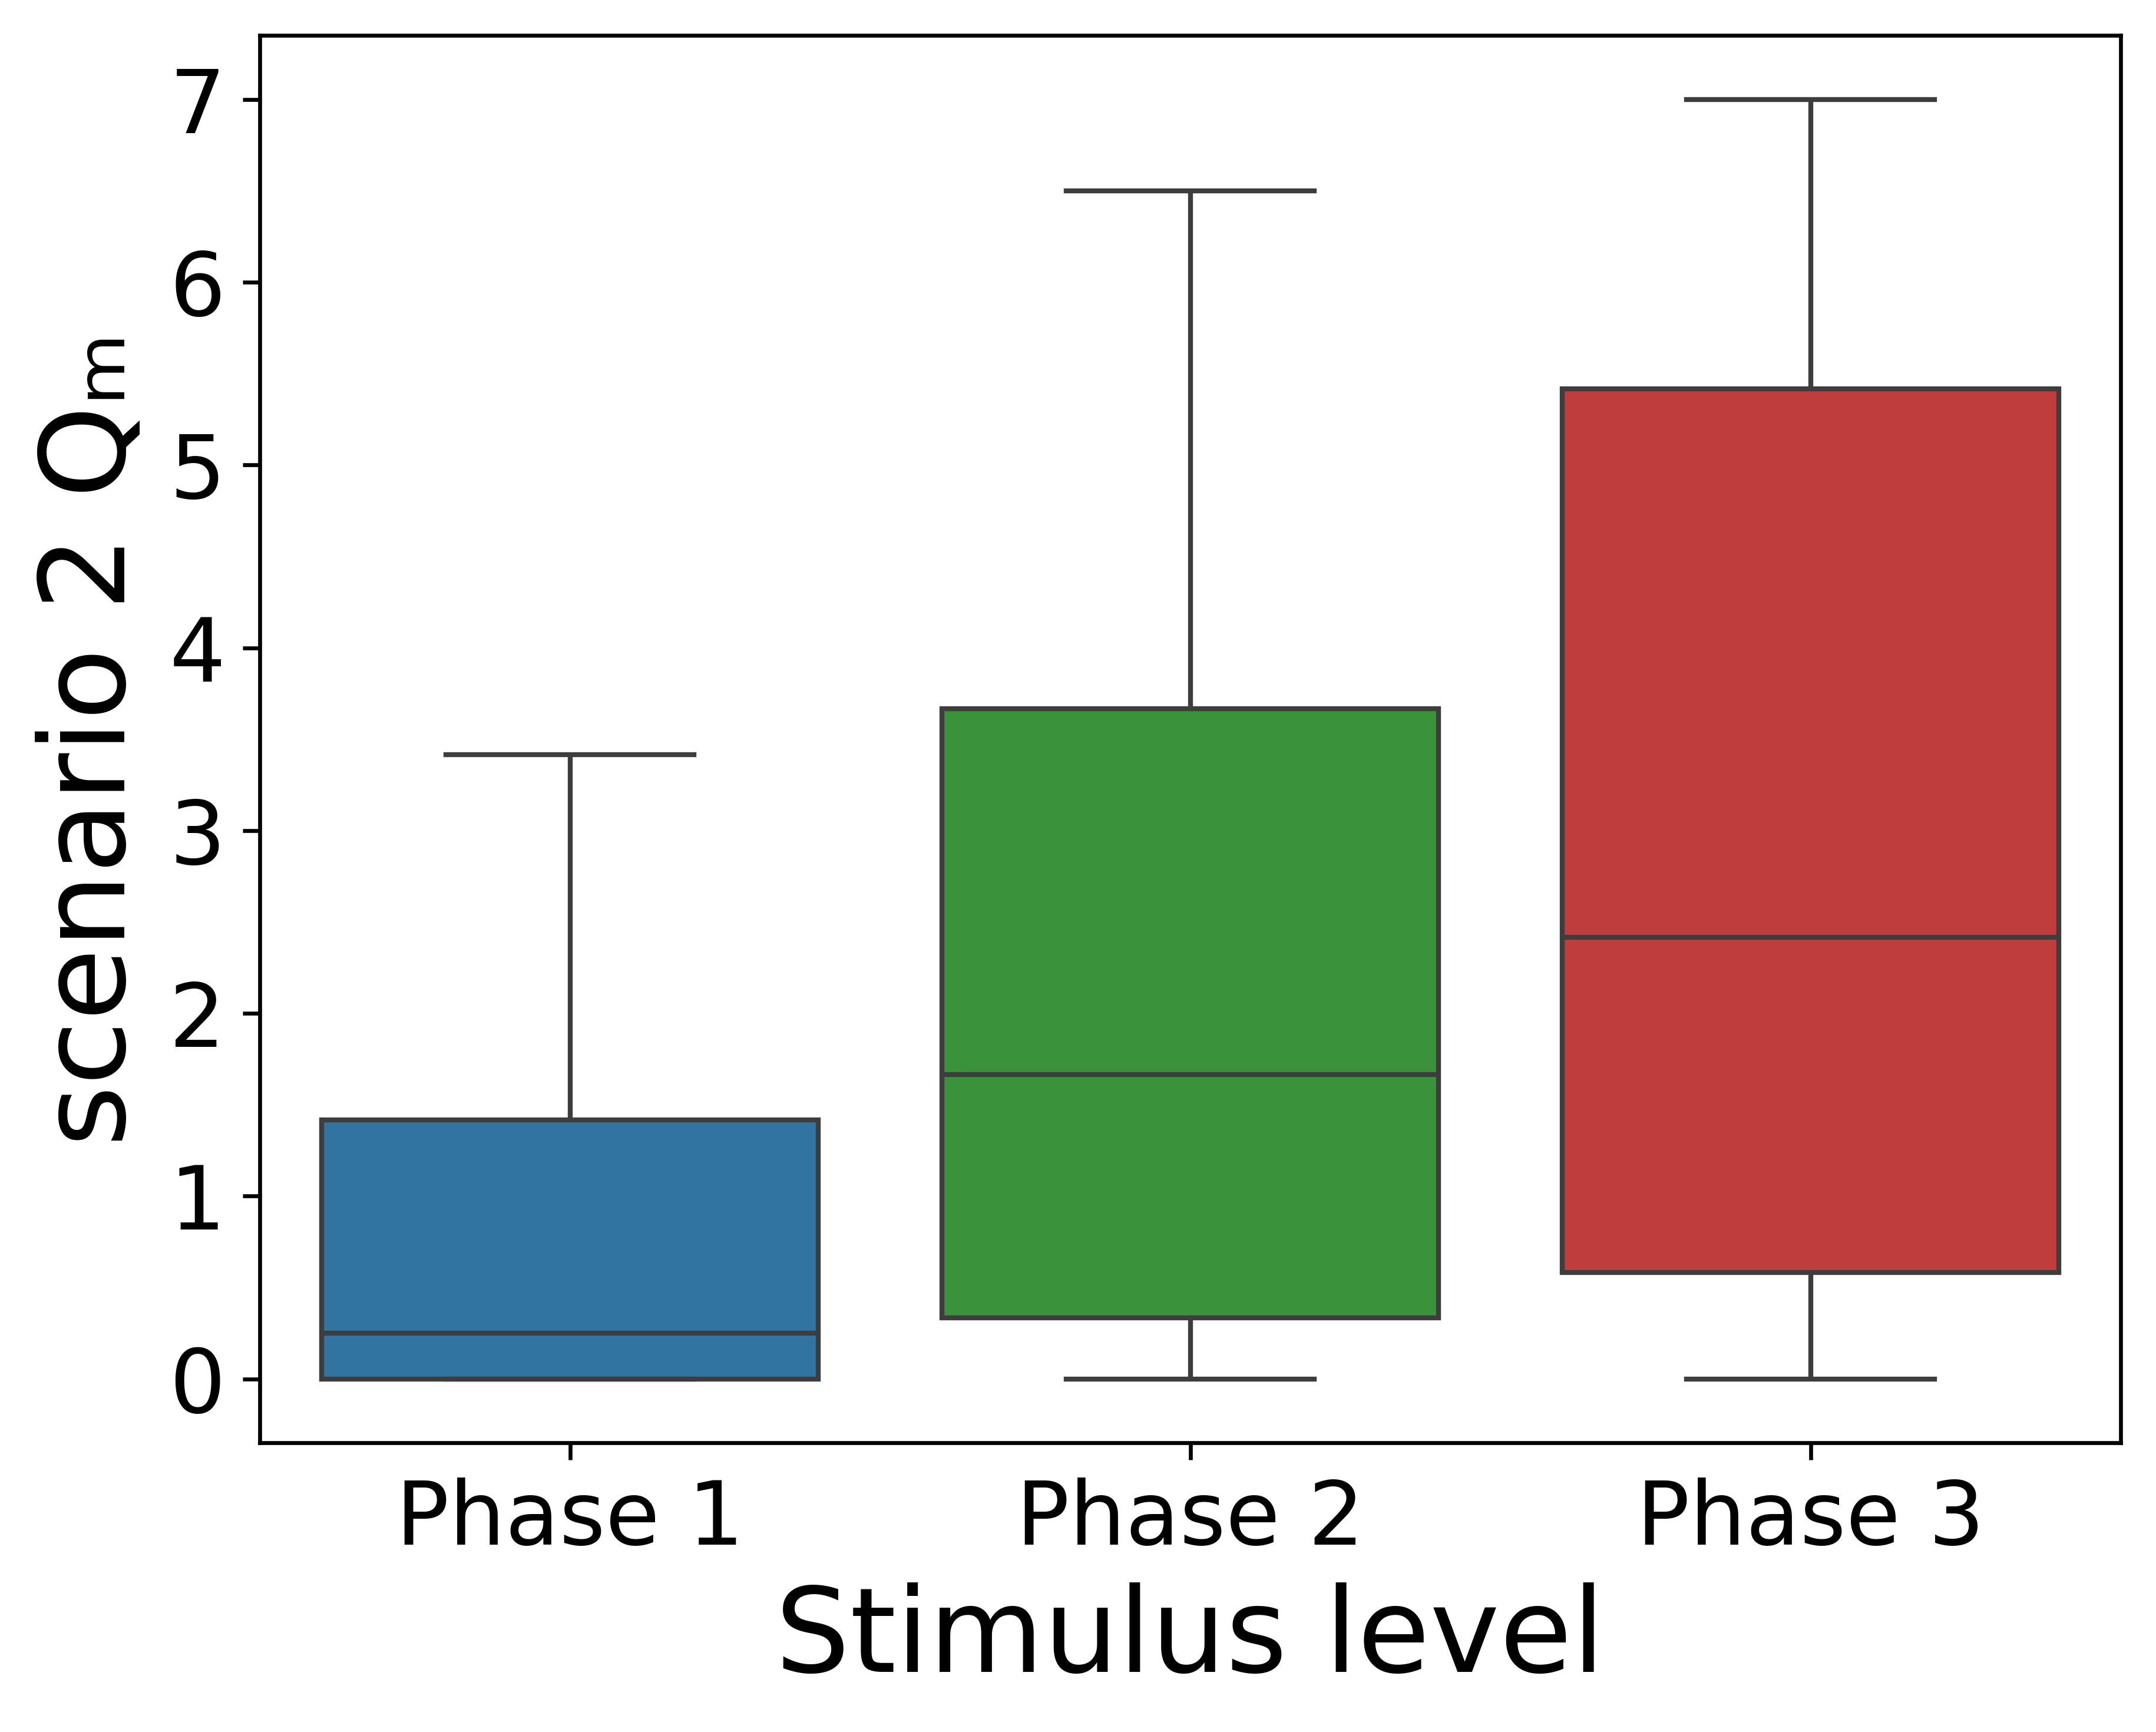

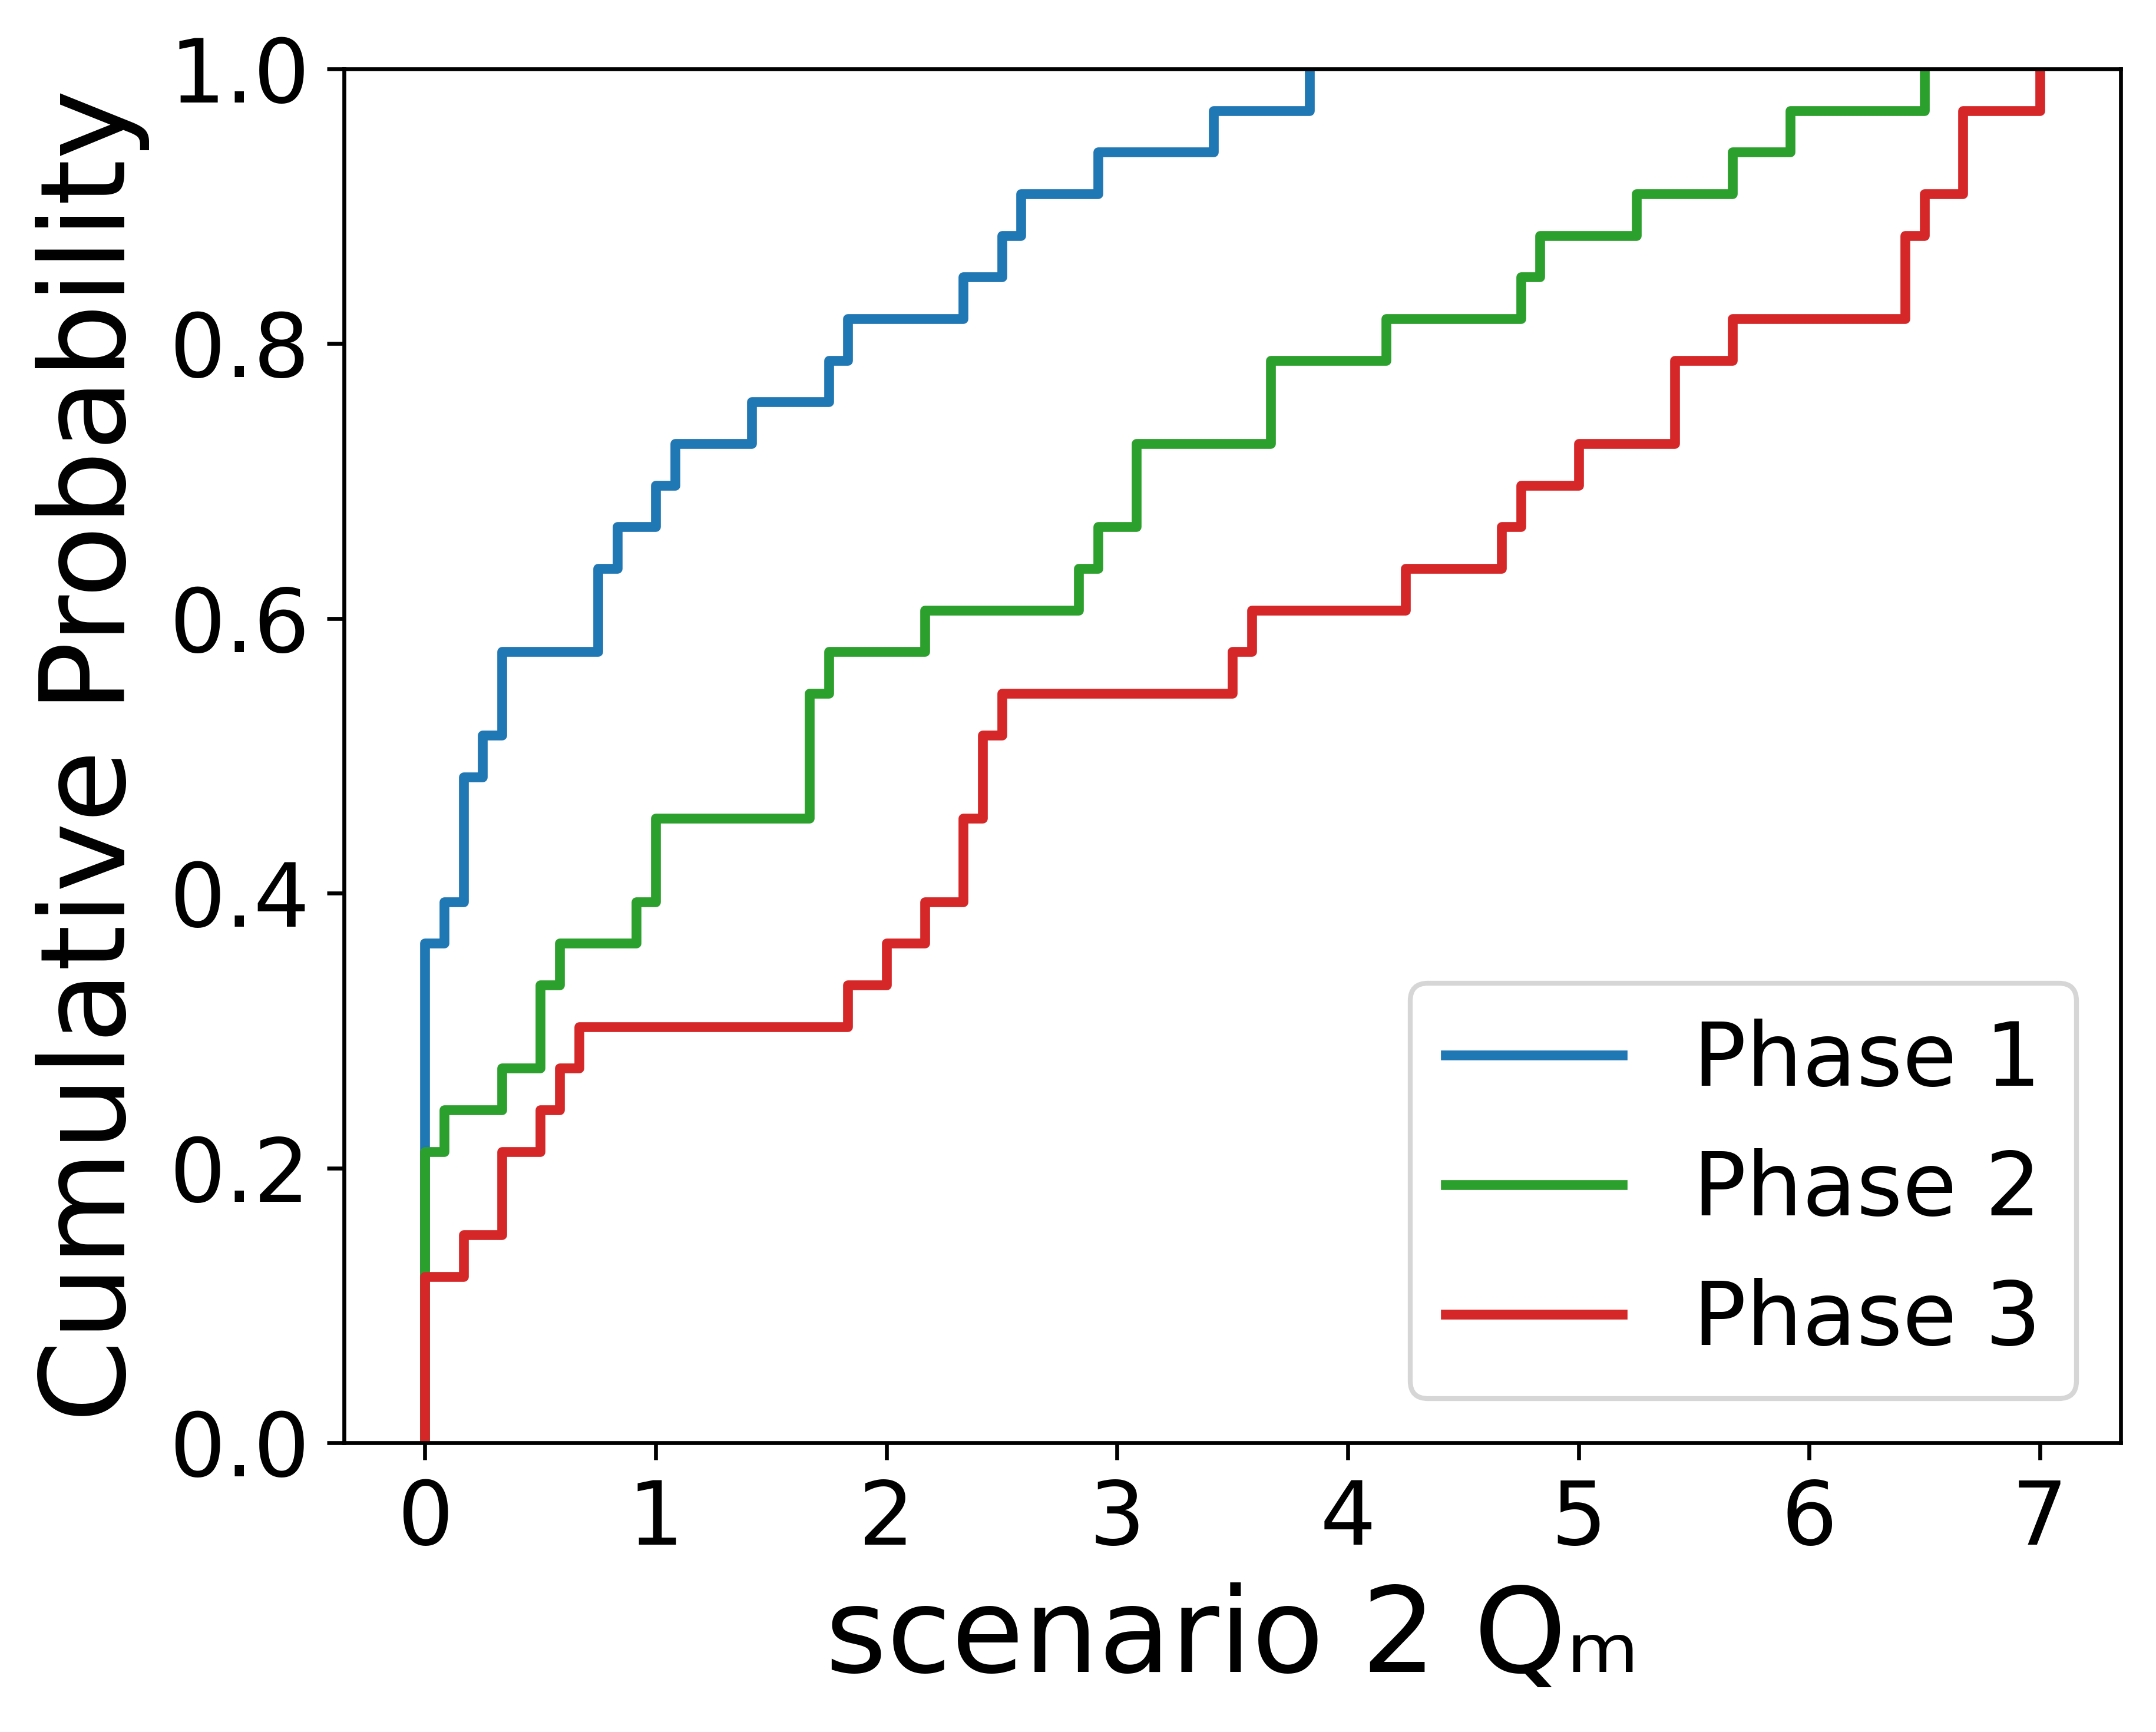

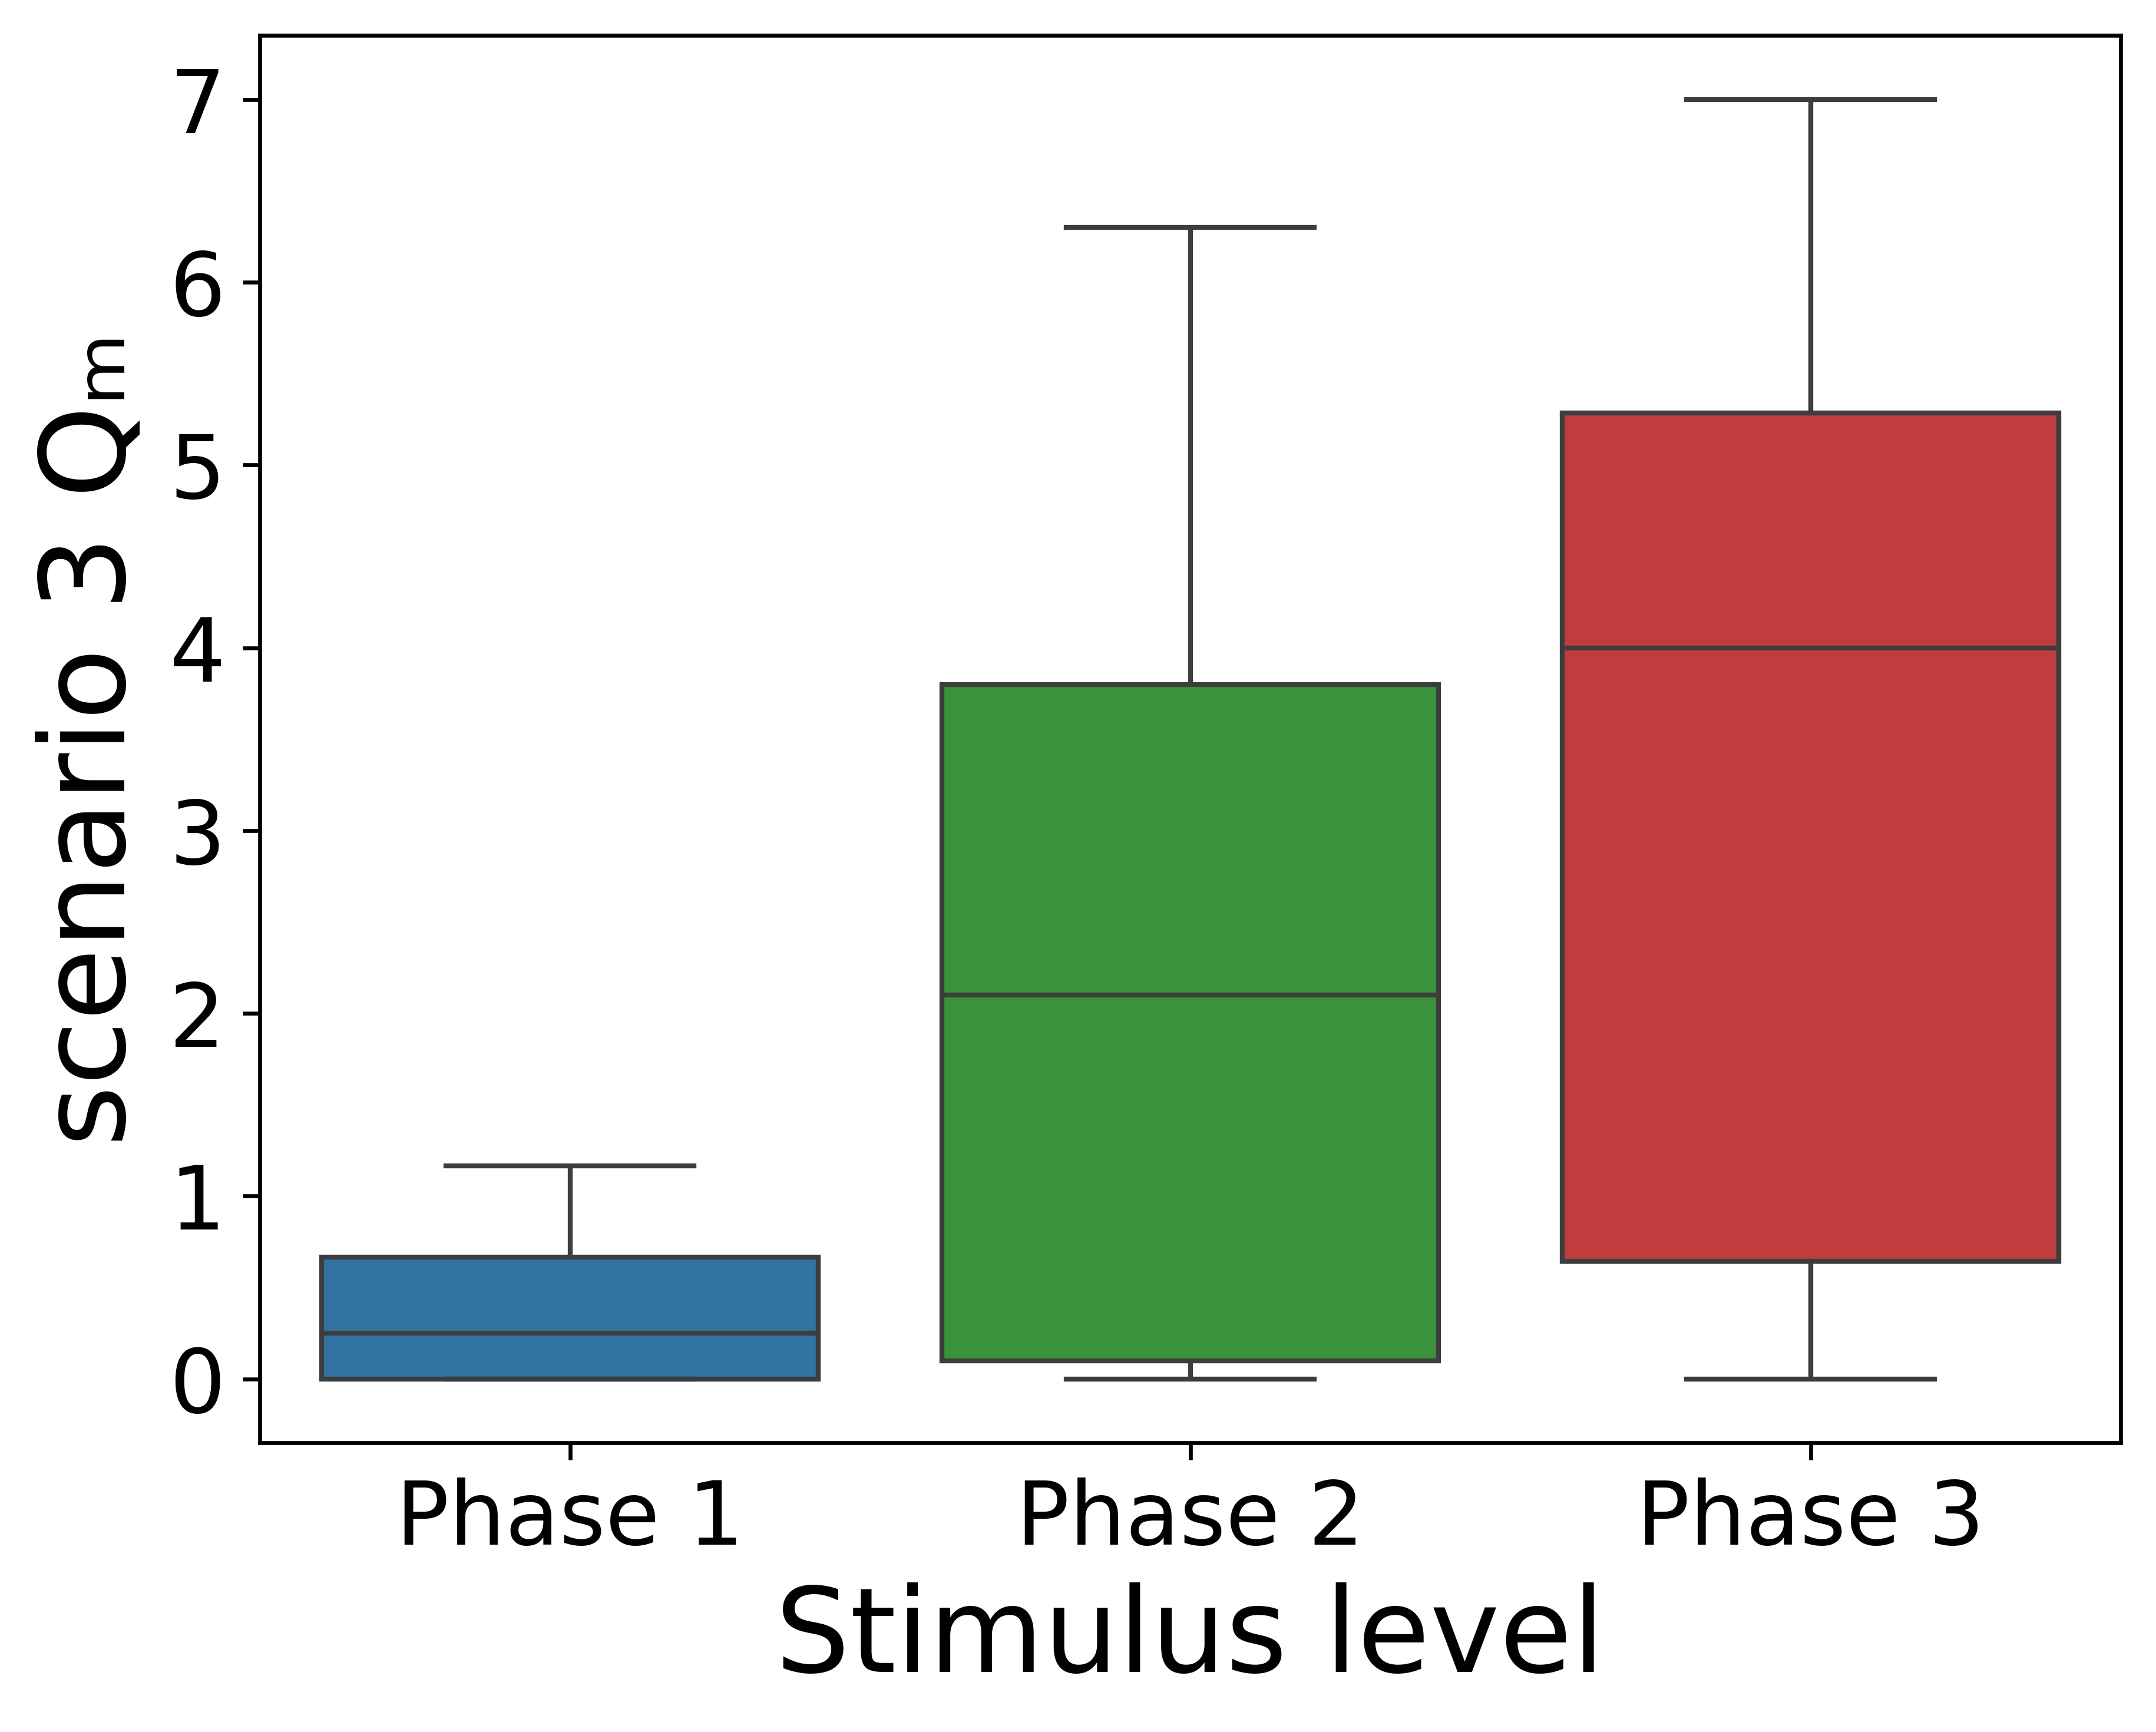

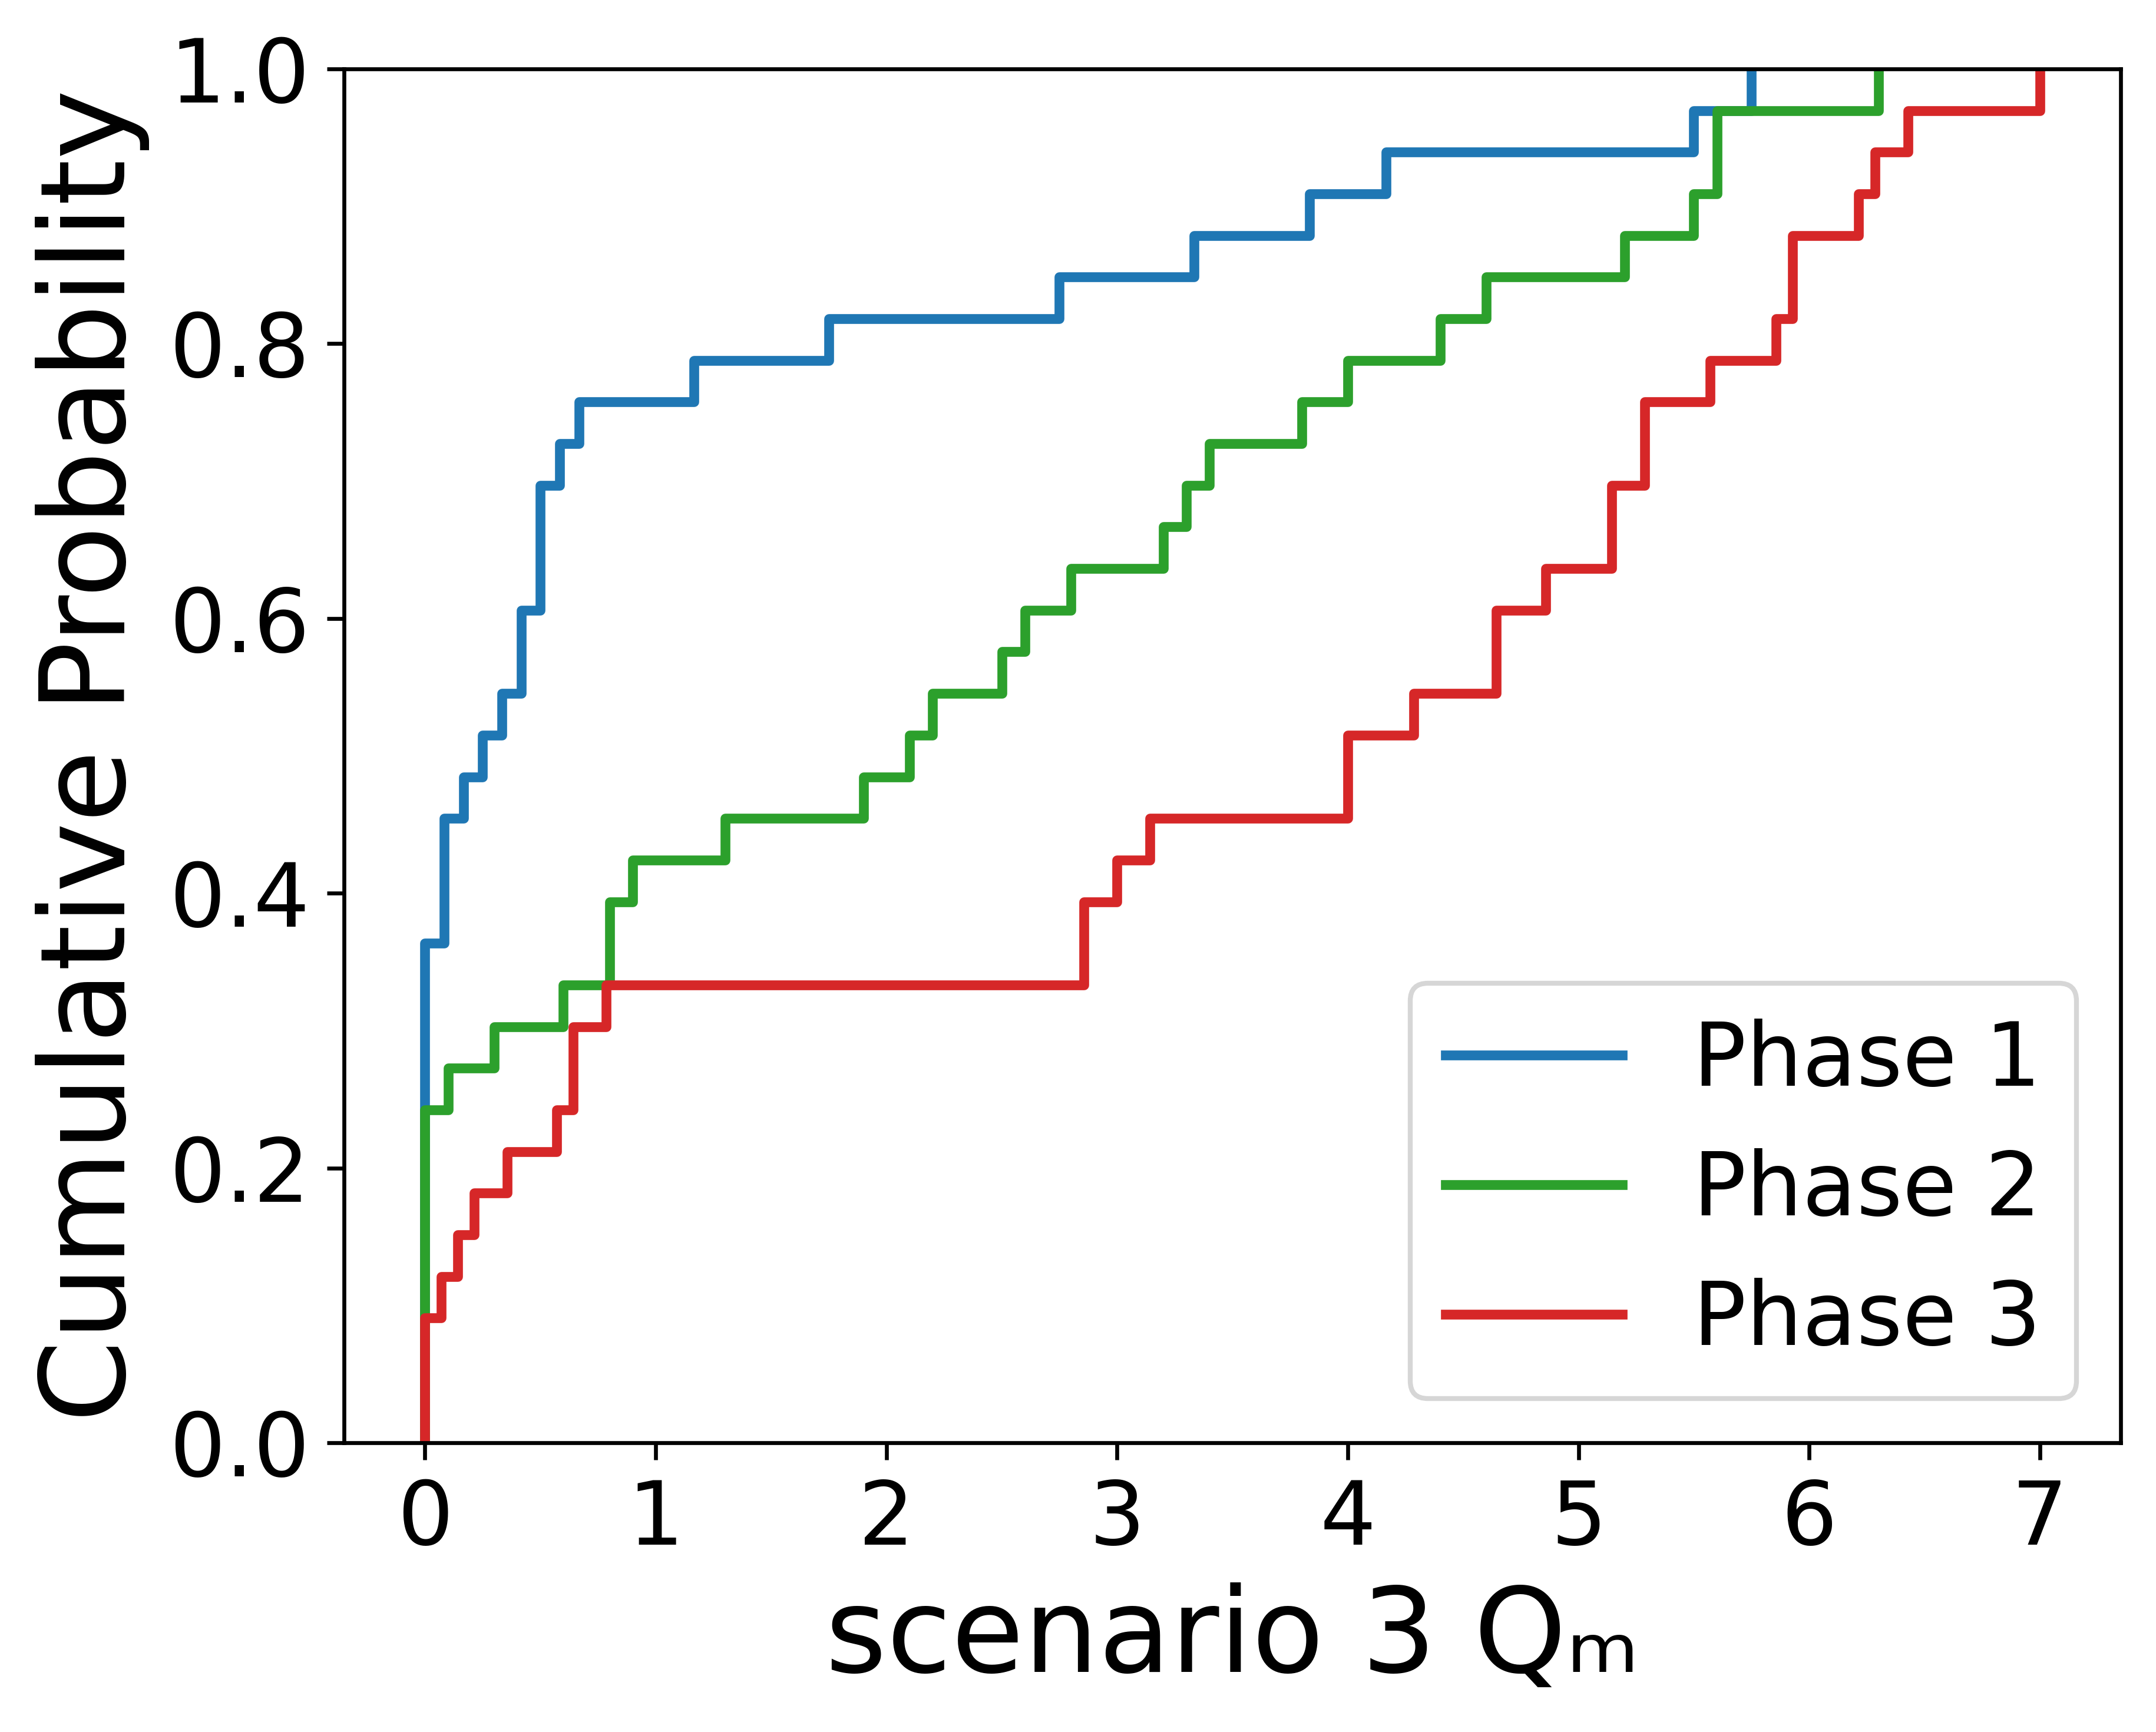

In [7]:
LEVEL_TICKS = [0, 1, 2]
LEVEL_NAMES = ["low", "mid", "high"]

# ✅ seaborn palette 매칭 문제 방지: int/str 키 둘 다 준비
LEVEL_COLORS = {
    0: "#1f77b4", "0": "#1f77b4",  # low
    1: "#2ca02c", "1": "#2ca02c",  # mid
    2: "#d62728", "2": "#d62728",  # high
}

def _bootstrap_ci_mean(x, n_boot=2000, ci=95, seed=42):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    return float(np.mean(x)), float(lo), float(hi)

LEVEL_NAMES = ["낮음", "중간", "높음"]

def plot_spearman_level_suite(
    df_long: pd.DataFrame,
    score_col: str = "score",
    level_col: str = "level",
    title_prefix: str = "Level vs Score",
    save_path: str | None = None,
    dpi: int = 600,
    seed: int = 42,
    mode: str = "Q1",
    add_strip: bool = False,
    strip_jitter: float = 0.22,
    strip_alpha: float = 0.25,
    strip_size: float = 2.5,
    add_mean_ci: bool = False,
):
    # --- clean ---
    d = df_long[[level_col, score_col]].copy()
    d[level_col] = pd.to_numeric(d[level_col], errors="coerce")
    d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
    d = d[np.isfinite(d[level_col]) & np.isfinite(d[score_col])].copy()

    # enforce levels 0/1/2
    d = d[d[level_col].isin(LEVEL_TICKS)].copy()

    # seaborn이 문자열로 인식하는 경우 방지
    d["level_int"] = d[level_col].astype(int)

    # --- spearman ---
    rho, p = spearmanr(d["level_int"].to_numpy(), d[score_col].to_numpy())
    res = {"rho": float(rho), "pval": float(p), "n": int(len(d))}

    # --- per-level mean + CI ---
    means, los, his = [], [], []
    for lv in LEVEL_TICKS:
        m, lo, hi = _bootstrap_ci_mean(
            d.loc[d["level_int"] == lv, score_col].to_numpy(),
            seed=seed + lv
        )
        means.append(m)
        los.append(lo)
        his.append(hi)

    # LEVEL_NAMES가 list일 수도 있고 dict일 수도 있으므로 표시용 이름 따로 처리
    if isinstance(LEVEL_NAMES, dict):
        level_name_list = [LEVEL_NAMES[lv] for lv in LEVEL_TICKS]
    else:
        level_name_list = LEVEL_NAMES

    res["level_mean"] = dict(zip(level_name_list, means))
    res["level_ci_lo"] = dict(zip(level_name_list, los))
    res["level_ci_hi"] = dict(zip(level_name_list, his))

    # 저장 경로 분리
    box_save_path = None
    ecdf_save_path = None
    if save_path is not None:
        save_path = str(save_path)
        if save_path.lower().endswith(".png"):
            box_save_path = save_path[:-4] + "_box.png"
            ecdf_save_path = save_path[:-4] + "_ecdf.png"
        else:
            box_save_path = save_path + "_box.png"
            ecdf_save_path = save_path + "_ecdf.png"

    # =========================
    # (A) boxplot - separate figure
    # =========================
    fig, ax = plt.subplots(figsize=(6.2, 5), dpi=dpi)

    sns.boxplot(
        data=d,
        x="level_int",
        y=score_col,
        order=LEVEL_TICKS,
        palette=LEVEL_COLORS,
        showfliers=False,
        ax=ax
    )

    if add_strip:
        sns.stripplot(
            data=d,
            x="level_int",
            y=score_col,
            order=LEVEL_TICKS,
            color="black",
            jitter=strip_jitter,
            alpha=strip_alpha,
            size=strip_size,
            ax=ax
        )

    if add_mean_ci:
        x_pos = np.arange(len(LEVEL_TICKS))
        yerr = np.vstack([
            np.array(means) - np.array(los),
            np.array(his) - np.array(means)
        ])
        ax.errorbar(
            x_pos,
            means,
            yerr=yerr,
            fmt="o",
            color="black",
            capsize=4,
            linewidth=1.5,
            zorder=5
        )

    ax.set_xticks(LEVEL_TICKS)
    ax.set_xticklabels(level_name_list)
    ax.set_xlabel("Stimulus level", fontsize=24)
    ax.set_ylabel(f"{mode}" if mode else score_col, fontsize=24)
    ax.set_yticks(np.arange(0, 7.01, 1))
    ax.tick_params(axis="both", which="major", labelsize=18)

    plt.tight_layout()
    if box_save_path:
        plt.savefig(box_save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    # =========================
    # (B) ECDF - separate figure
    # =========================
    fig, ax = plt.subplots(figsize=(6.2, 5), dpi=dpi)

    for lv, name in zip(LEVEL_TICKS, level_name_list):
        sns.ecdfplot(
            data=d[d["level_int"] == lv],
            x=score_col,
            ax=ax,
            label=name,
            color=LEVEL_COLORS[lv],
            linewidth=2
        )

    ax.set_xlabel(f"{mode}" if mode else score_col, fontsize=24)
    ax.set_ylabel("Cumulative Probability", fontsize=24)
    ax.set_xticks(np.arange(0, 7.01, 1))
    ax.tick_params(axis="both", which="major", labelsize=18)
    ax.legend(fontsize=18)

    plt.tight_layout()
    if ecdf_save_path:
        plt.savefig(ecdf_save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    return res, d

LEVEL_MAP = {"low": 0, "mid": 1, "high": 2}
LEVEL_NAMES = {0: "Phase 1", 1: "Phase 2", 2: "Phase 3"}
LEVEL_ORDER = [0, 1, 2]


# =========================
# 0) Labels -> long df
# =========================
def _level_to_int(trial_name: str) -> int:
    for k, v in LEVEL_MAP.items():
        if str(trial_name).startswith(k):
            return v
    return -1

def _score_from_q(d: dict, mode: str) -> float:
    q1 = d.get("Q1", np.nan)
    q2 = d.get("Q2", np.nan)
    if mode == "Q1":
        return float(q1)
    if mode == "Q2":
        return float(q2)
    if mode == "mean":
        return float(np.nanmean([q1, q2]))
    raise ValueError("mode must be one of {'Q1','Q2','mean'}")

def flatten_labels(labels: dict, mode: str = "Q1") -> pd.DataFrame:
    rows = []
    for subj, subj_dict in labels.items():
        for video, video_dict in subj_dict.items():     # "V1","V2"
            for trial, qdict in video_dict.items():     # "low1","mid3",...
                lv = _level_to_int(trial)
                rows.append({
                    "subject": str(subj),
                    "video": str(video),
                    "trial": str(trial),
                    "level": lv,
                    "score": _score_from_q(qdict, mode),
                })
    df = pd.DataFrame(rows)
    df["session"] = df["subject"] + "_" + df["video"]
    df["level"] = pd.to_numeric(df["level"], errors="coerce")
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    df = df[(df["level"].isin(LEVEL_ORDER)) & np.isfinite(df["score"])].copy()
    df["level"] = df["level"].astype(int)
    return df

# =========================
# 2) Level-mean transforms
# =========================
def make_level_mean_df(df_long: pd.DataFrame, group_cols=("session", "level")) -> pd.DataFrame:
    # e.g., per-session per-level mean score
    d = (
        df_long.groupby(list(group_cols), as_index=False)["score"]
        .mean()
        .rename(columns={"score": "mean_score"})
    )
    d["level"] = d["level"].astype(int)
    d["mean_score"] = pd.to_numeric(d["mean_score"], errors="coerce")
    d = d[np.isfinite(d["mean_score"])].copy()
    return d

df_session_scenario = pd.read_csv(SCENARIO_INFO_CSV)
df_q_mean_long = flatten_labels(labels=labels, mode='mean')

df = pd.merge(df_q_mean_long, df_session_scenario, on=["subject","video"], how="inner")

df_q_mean_lvmean = make_level_mean_df(df, group_cols=("session", "level"))
res, d_clean = plot_spearman_level_suite(
    df_q_mean_lvmean,
    score_col="mean_score",
    level_col="level",
    title_prefix="Stimulus level vs Q\u2098",
    save_path=RUNS_DIR / "level_vs_Q_mean.png",
    mode = "Q\u2098"
)

df_s1 = df[df["scenario"] == 1].reset_index(drop=True)
df_s2 = df[df["scenario"] == 2].reset_index(drop=True)
df_s3 = df[df["scenario"] == 3].reset_index(drop=True)

df_q_mean_lvmean_s1 = make_level_mean_df(df_s1, group_cols=("session", "level"))
res, d_clean = plot_spearman_level_suite(
    df_q_mean_lvmean_s1,
    score_col="mean_score",
    level_col="level",
    title_prefix="Stimulus level vs Q\u2098",
    save_path=RUNS_DIR / "level_vs_Q_mean_scenario1.png",
    mode = "scenario 1 Q\u2098"
)

df_q_mean_lvmean_s2 = make_level_mean_df(df_s2, group_cols=("session", "level"))
res, d_clean = plot_spearman_level_suite(
    df_q_mean_lvmean_s2,
    score_col="mean_score",
    level_col="level",
    title_prefix="Stimulus level vs Q\u2098",
    save_path=RUNS_DIR / "level_vs_Q_mean_scenario2.png",
    mode = "scenario 2 Q\u2098"
)

df_q_mean_lvmean_s3 = make_level_mean_df(df_s3, group_cols=("session", "level"))
res, d_clean = plot_spearman_level_suite(
    df_q_mean_lvmean_s3,
    score_col="mean_score",
    level_col="level",
    title_prefix="Stimulus level vs Q\u2098",
    save_path=RUNS_DIR / "level_vs_Q_mean_scenario3.png",
    mode = "scenario 3 Q\u2098"
)


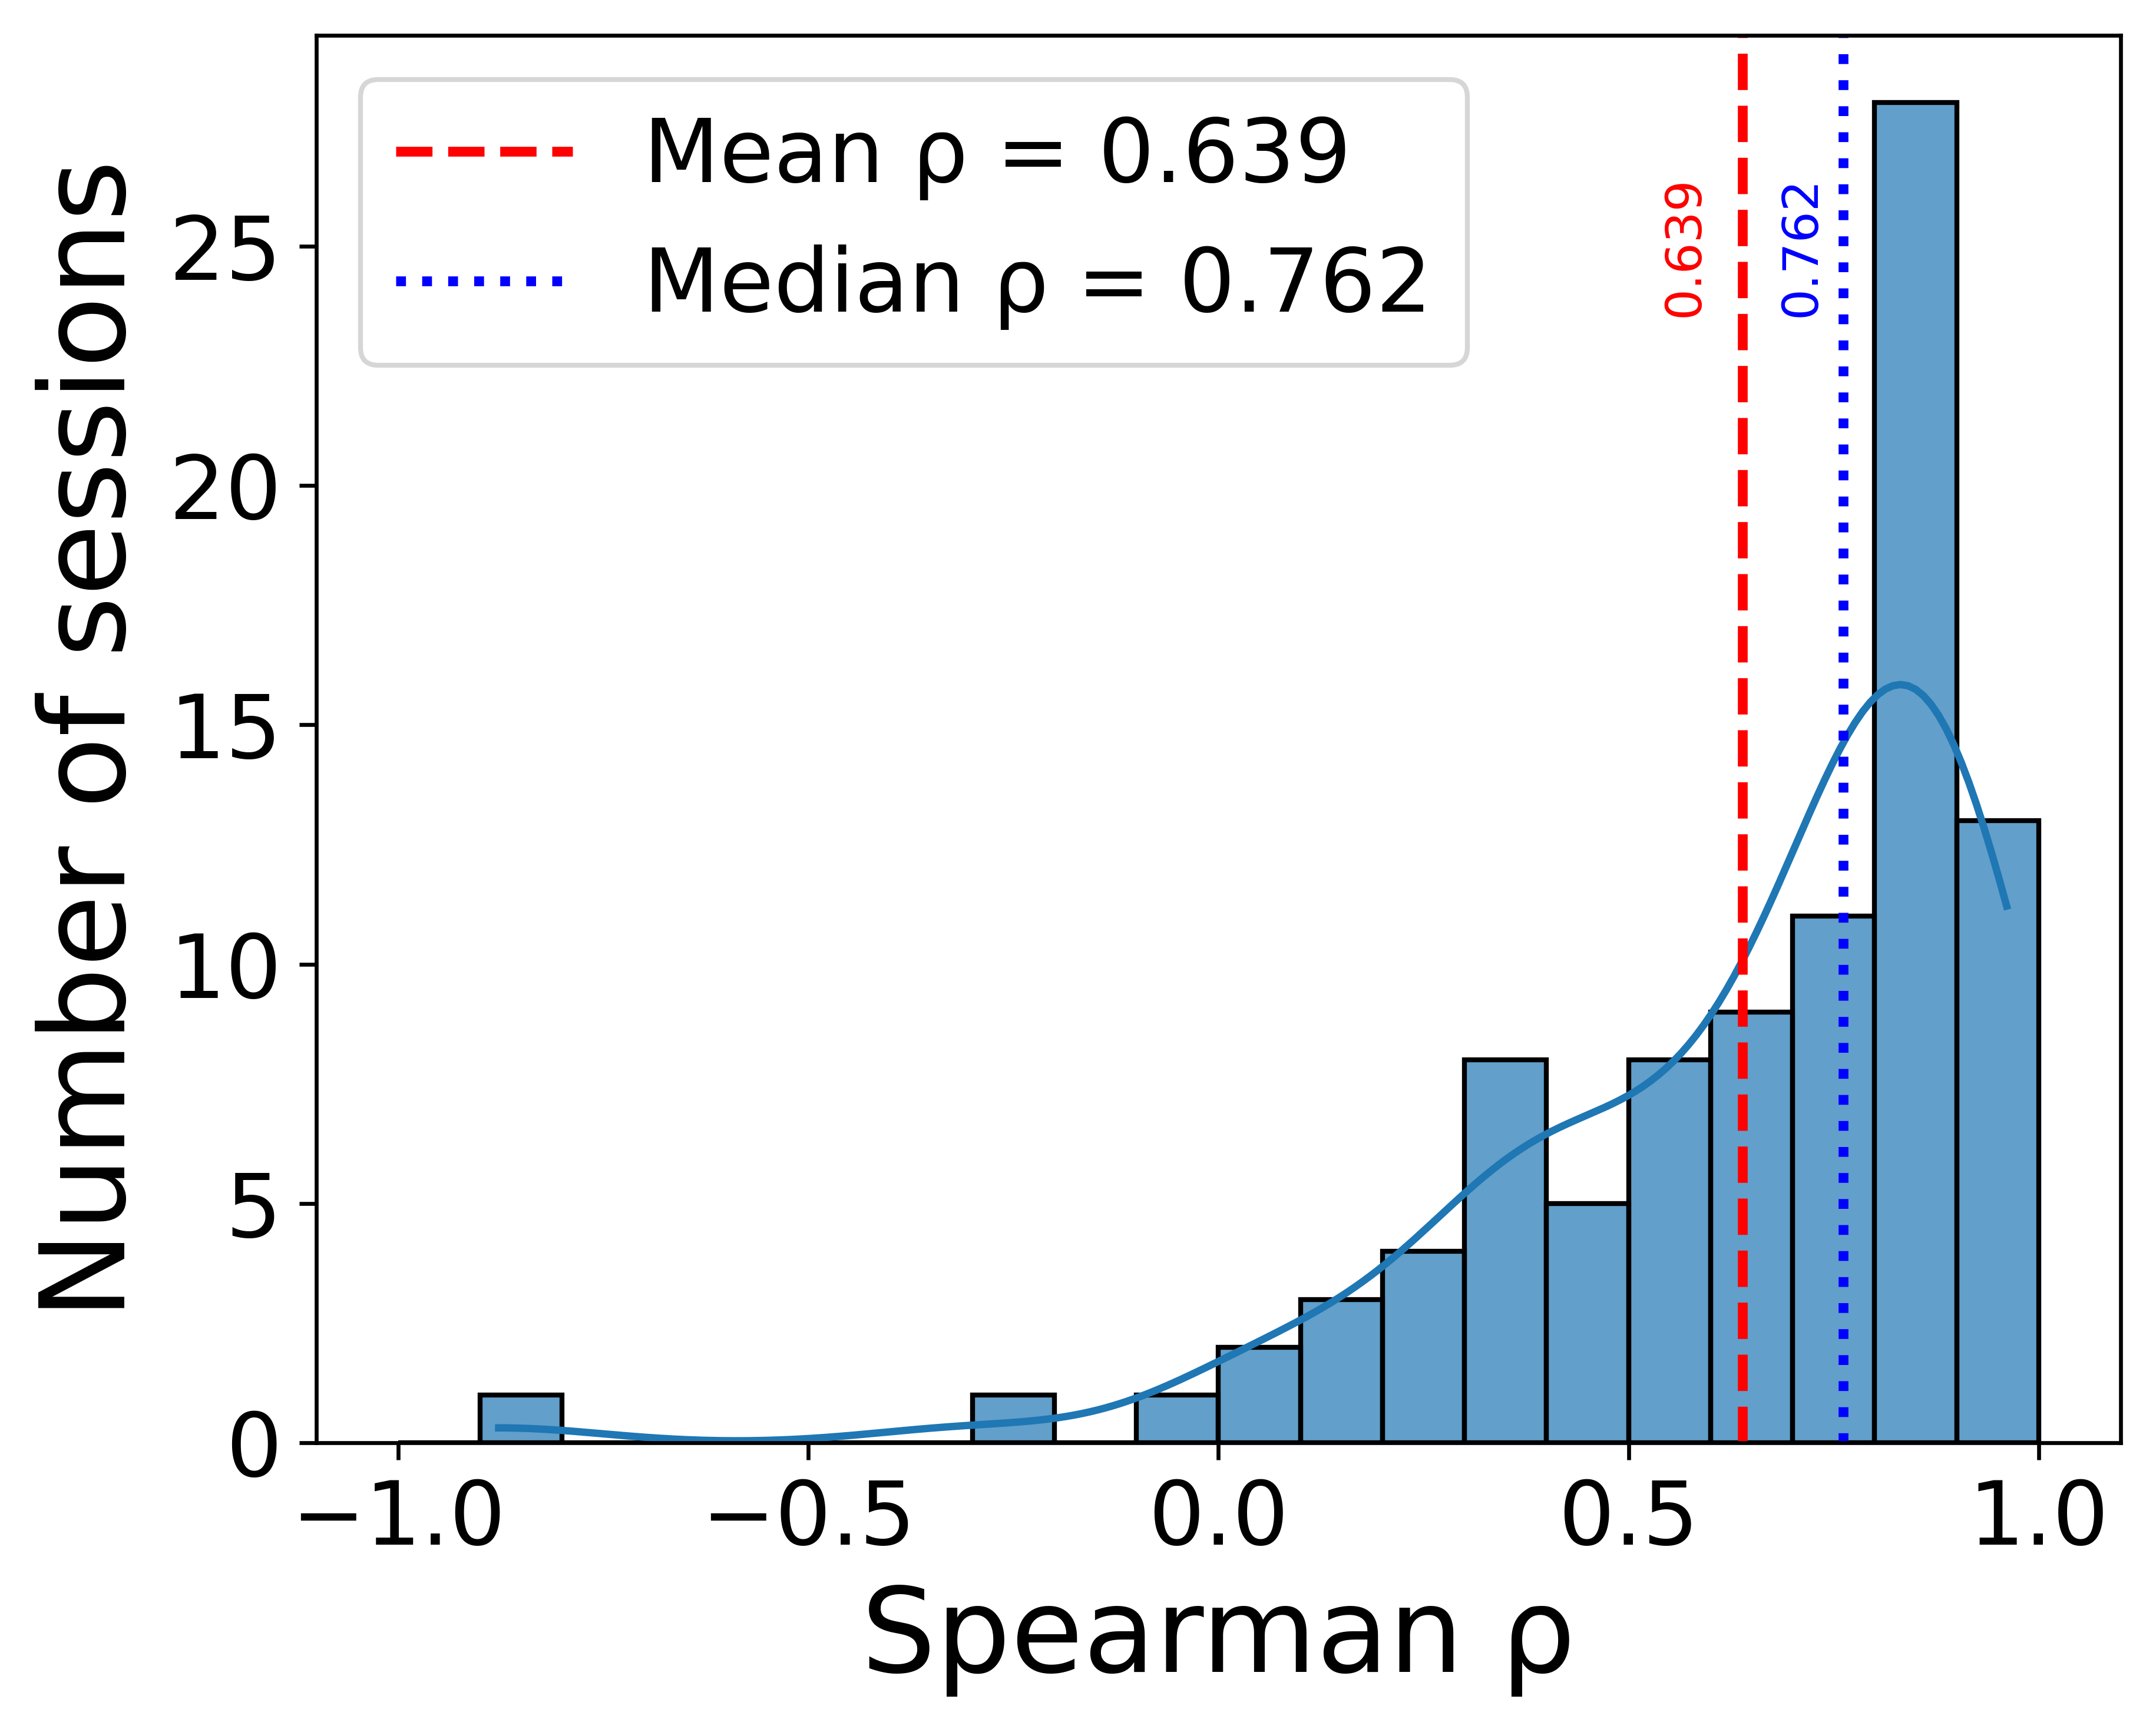

{'mean': 0.6386756266525446, 'median': 0.7618627761474079, 'n': 94}

In [8]:
def _safe_spearman(x: np.ndarray, y: np.ndarray):
    x = np.asarray(x)
    y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 2:
        return np.nan, np.nan, int(len(x))
    if np.unique(x).size < 2:
        return np.nan, np.nan, int(len(x))
    if np.unique(y).size < 2:
        return np.nan, np.nan, int(len(x))
    rho, p = spearmanr(x, y)
    return float(rho), float(p), int(len(x))

def corr_global(df: pd.DataFrame, x_col="level", y_col="score") -> dict:
    rho, p, n = _safe_spearman(df[x_col].to_numpy(), df[y_col].to_numpy())
    return {"rho": rho, "pval": p, "n": n}

def corr_by_group(df: pd.DataFrame, group_col: str, x_col="level", y_col="score") -> pd.DataFrame:
    rows = []
    for g, d in df.groupby(group_col, sort=False):
        rho, p, n = _safe_spearman(d[x_col].to_numpy(), d[y_col].to_numpy())
        rows.append({
            group_col: str(g),
            "rho": rho,
            "pval": p,
            "n": n,
            "n_unique_x": int(np.unique(d[x_col]).size),
            "n_unique_y": int(np.unique(d[y_col]).size),
        })
    out = pd.DataFrame(rows)
    out = out.sort_values("rho", ascending=False, na_position="last").reset_index(drop=True)
    return out

def mean_rho_excluding_nan(df_corr: pd.DataFrame, rho_col="rho") -> dict:
    v = pd.to_numeric(df_corr[rho_col], errors="coerce")
    v = v[np.isfinite(v)]
    return {
        "mean_rho": float(v.mean()) if len(v) else np.nan,
        "std_rho": float(v.std(ddof=1)) if len(v) > 1 else np.nan,
        "median_rho": float(v.median()) if len(v) else np.nan,
        "n_valid": int(len(v)),
        "n_total": int(len(df_corr)),
    }


def plot_rho_distribution(df, rho_col="rho", title=None, save_path=None):
    """
    Histogram of Spearman rho with mean/median vertical lines.
    - KDE off by default (cleaner for slides). Set kde=True if you want.
    """
    fig, ax = plt.subplots(figsize=(6.2, 5), dpi=600)

    # bin edges: -1~1, step=0.1
    bins = np.linspace(-1, 1, 21)

    # drop NaN
    x = df[rho_col].dropna()

    sns.histplot(
        x,
        bins=bins,
        kde=True,                 # 🔧 cleaner for presentation
        stat="count",
        edgecolor="black",
        alpha=0.7,
        ax=ax
    )

    # mean / median
    rho_mean = float(x.mean())
    rho_median = float(x.median())

    # vertical lines
    ax.axvline(rho_mean, color="red", linestyle="--", linewidth=2,
               label=f"Mean ρ = {rho_mean:.3f}")
    ax.axvline(rho_median, color="blue", linestyle=":", linewidth=2,
               label=f"Median ρ = {rho_median:.3f}")

    # annotations (slightly lower to avoid touching the top)
    ymax = ax.get_ylim()[1]
    ax.text(rho_mean-0.07, ymax * 0.90, f"{rho_mean:.3f}",
            color="red", ha="center", va="top",
            fontsize=10, rotation=90, 
            # backgroundcolor="white"
            )
    ax.text(
        rho_median - 0.08,   # 👉 왼쪽으로 이동
        ymax * 0.90,
        f"{rho_median:.3f}",
        color="blue",
        ha="left",
        va="top",
        fontsize=10,
        rotation=90,          # 👉 세로 대신 가로
        # backgroundcolor="white"
    )

    # labels
    ax.set_xlabel("Spearman ρ", fontsize=24)
    ax.set_ylabel("Number of sessions", fontsize=24)
    ax.set_xticks(np.arange(-1.0, 1.01, 0.5))
    ax.tick_params(axis="both", which="major", labelsize=18)

    if title is not None:
        ax.set_title(title, fontsize=18)

    ax.legend(fontsize=18, loc="upper left")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.show()

    return {"mean": rho_mean, "median": rho_median, "n": int(x.shape[0])}


def plot_rho_ecdf(df1, df2, dfm, rho_col="rho", title=None, save_path=None):
    """
    ECDF comparison for Q1 / Q2 / Q_mean.
    """
    fig, ax = plt.subplots(figsize=(5, 4), dpi=600)

    sns.ecdfplot(df1[rho_col].dropna(), ax=ax, label="Q1")
    sns.ecdfplot(df2[rho_col].dropna(), ax=ax, label="Q2")
    sns.ecdfplot(dfm[rho_col].dropna(), ax=ax, label="Q_mean")

    ax.set_xlabel("Spearman ρ", fontsize=16)
    ax.set_ylabel("Cumulative probability", fontsize=16)
    ax.set_xticks(np.arange(-1.0, 1.01, 0.5))
    ax.tick_params(axis="both", which="major", labelsize=14)

    if title is not None:
        ax.set_title(title, fontsize=16)

    ax.legend(fontsize=14, loc="upper left")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.show()

df_q_mean_long = flatten_labels(labels, mode='mean')
df_q_mean_sess = corr_by_group(df_q_mean_long, group_col="session", x_col="level", y_col="score")
# df_lvmean = make_level_mean_df(df_long, group_cols=("session", "level"))
# df_lvmean_sess = corr_by_group(df_lvmean, group_col="session", x_col="level", y_col="mean_score")
plot_rho_distribution(df_q_mean_sess, save_path = RUNS_DIR / "histogram_spearman_corr_by_sessions.png" )
# plot_rho_distribution(df_lvmean_sess)



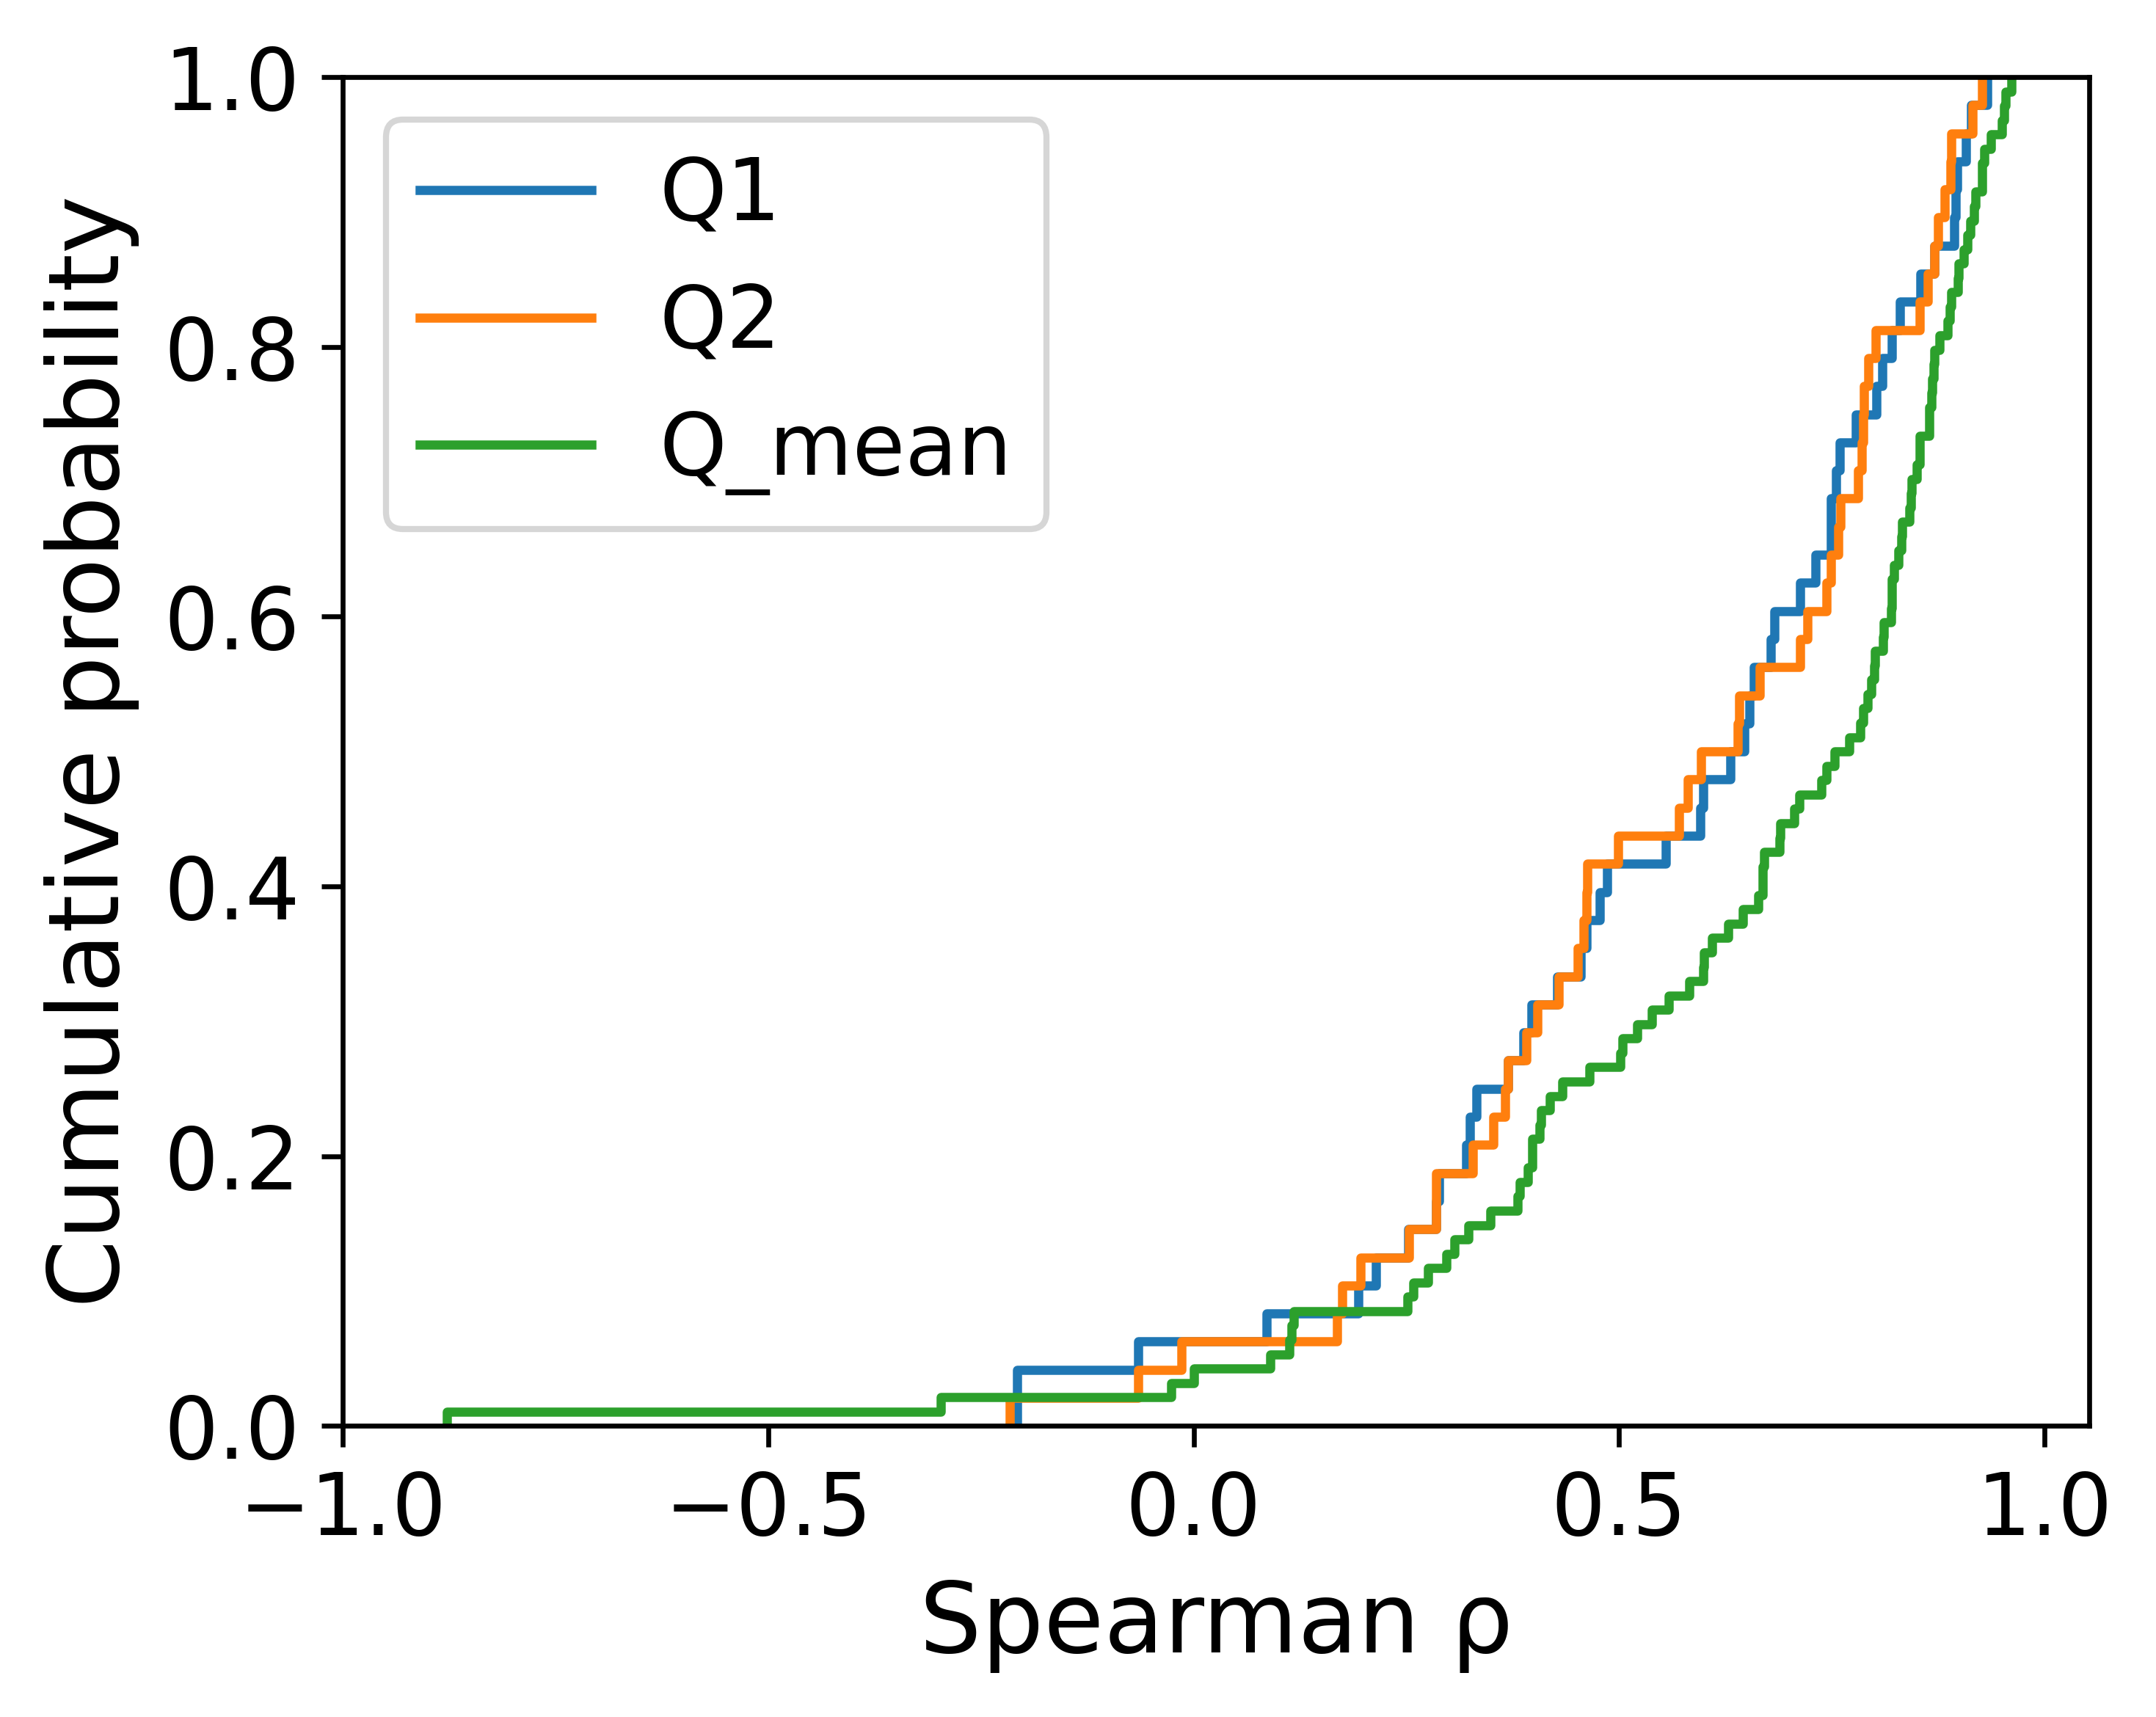

In [9]:
df_q1_long = flatten_labels(labels, mode='Q1')
df_q1_sess = corr_by_group(df_q1_long, group_col="subject", x_col="level", y_col="score")

df_q2_long = flatten_labels(labels, mode='Q2')
df_q2_sess = corr_by_group(df_q2_long, group_col="subject", x_col="level", y_col="score")

plot_rho_ecdf(df_q1_sess, df_q2_sess, df_q_mean_sess)
